# Notebook version: v1.2

# Working with GitHub

## Git imports

In [ ]:
from datetime import datetime, timezone
from pathlib import Path
import subprocess

## Git constants

In [ ]:
DRIVE_MOUNT_POINT = Path('/content/drive')
COLAB_REPO_PATH = DRIVE_MOUNT_POINT / 'MyDrive' / 'patternsR-D'
LOCAL_REPO_PATH = Path.cwd()
GIT_REMOTE = 'origin'
GIT_BRANCH = 'main'
NOTEBOOK_FILE = 'doubleTop_DoubleBottom_detection.ipynb'

## Git sync functions

In [13]:
def run_git(repo_path, *args, capture_output=False, check=True):
    result = subprocess.run(
        ['git', *args],
        cwd=repo_path,
        check=False,
        text=True,
        capture_output=True,
    )
    if not capture_output:
        if result.stdout:
            print(result.stdout, end='')
        if result.stderr:
            print(result.stderr, end='')
    if check and result.returncode != 0:
        command = ' '.join(['git', *args])
        details = result.stderr.strip() or result.stdout.strip()
        raise RuntimeError(
            f'Git command failed ({result.returncode}): {command}\n{details}'
        )
    return result


def require_main_branch(repo_path):
    if not (repo_path / '.git').exists():
        raise RuntimeError(f'Git clone не найден: {repo_path}')

    branch = run_git(
        repo_path,
        'branch', '--show-current', capture_output=True
    ).stdout.strip()
    if branch != GIT_BRANCH:
        raise RuntimeError(
            f'Ожидалась ветка {GIT_BRANCH}, но активна {branch!r}.'
        )


def print_sync_status(repo_path, message):
    revision = run_git(
        repo_path,
        'log', '-1', '--format=%h %ad %s', '--date=iso-strict',
        capture_output=True,
    ).stdout.strip()
    print(f'{message}: {revision}')
    run_git(repo_path, 'status', '--short', '--branch')


def ensure_git_identity(repo_path):
    """Проверяет identity commit и при необходимости берёт её из Colab Secrets."""
    name = run_git(
        repo_path, 'config', '--get', 'user.name',
        capture_output=True, check=False,
    ).stdout.strip()
    email = run_git(
        repo_path, 'config', '--get', 'user.email',
        capture_output=True, check=False,
    ).stdout.strip()

    if not name or not email:
        try:
            from google.colab import userdata
            name = name or userdata.get('GIT_USER_NAME')
            email = email or userdata.get('GIT_USER_EMAIL')
        except Exception:
            pass

    if not name or not email:
        raise RuntimeError(
            'Git identity не настроена. Выполни в clone:\n'
            "git config user.name 'Your Name'\n"
            "git config user.email 'you@example.com'\n"
            'или создай Colab Secrets GIT_USER_NAME и GIT_USER_EMAIL.'
        )

    run_git(repo_path, 'config', 'user.name', name)
    run_git(repo_path, 'config', 'user.email', email)


def hard_sync_colab():
    """Монтирует Drive и жёстко синхронизирует Colab clone с origin/main."""
    from google.colab import drive

    if not (DRIVE_MOUNT_POINT / 'MyDrive').is_dir():
        drive.mount(str(DRIVE_MOUNT_POINT))
    if not COLAB_REPO_PATH.is_dir():
        raise FileNotFoundError(f'Git clone не найден: {COLAB_REPO_PATH}')

    require_main_branch(COLAB_REPO_PATH)
    run_git(COLAB_REPO_PATH, 'fetch', GIT_REMOTE, GIT_BRANCH)
    run_git(
        COLAB_REPO_PATH,
        'reset', '--hard', f'{GIT_REMOTE}/{GIT_BRANCH}',
    )
    print_sync_status(COLAB_REPO_PATH, 'Colab синхронизирован')


def push_colab_outputs():
    """Коммитит и отправляет только notebook с Colab outputs."""
    if not COLAB_REPO_PATH.is_dir():
        raise FileNotFoundError(f'Git clone не найден: {COLAB_REPO_PATH}')

    require_main_branch(COLAB_REPO_PATH)
    notebook_path = COLAB_REPO_PATH / NOTEBOOK_FILE
    if not notebook_path.is_file():
        raise FileNotFoundError(f'Notebook не найден: {notebook_path}')

    # Перед вызовом этой функции сначала сохрани notebook.
    run_git(COLAB_REPO_PATH, 'add', '--', NOTEBOOK_FILE)
    staged_diff = run_git(
        COLAB_REPO_PATH,
        'diff', '--cached', '--quiet', '--', NOTEBOOK_FILE,
        check=False,
    )
    if staged_diff.returncode == 0:
        print('Новых изменений notebook для commit нет.')
        return
    if staged_diff.returncode != 1:
        raise RuntimeError('Не удалось проверить staged diff notebook.')

    ensure_git_identity(COLAB_REPO_PATH)
    commit_message = (
        'Save Colab outputs '
        f"{datetime.now(timezone.utc).astimezone().isoformat(timespec='seconds')}"
    )
    run_git(COLAB_REPO_PATH, 'commit', '-m', commit_message)
    run_git(COLAB_REPO_PATH, 'push', GIT_REMOTE, GIT_BRANCH)
    print_sync_status(COLAB_REPO_PATH, 'Outputs отправлены')


def hard_sync_local():
    """Жёстко синхронизирует локальный clone с origin/main."""
    require_main_branch(LOCAL_REPO_PATH)
    run_git(LOCAL_REPO_PATH, 'fetch', GIT_REMOTE, GIT_BRANCH)
    run_git(
        LOCAL_REPO_PATH,
        'reset', '--hard', f'{GIT_REMOTE}/{GIT_BRANCH}',
    )
    print_sync_status(LOCAL_REPO_PATH, 'Локальная копия синхронизирована')

Локальная копия синхронизирована: c8b9128 2026-07-15T17:13:15+03:00 Automate GitHub and Colab synchronization


CompletedProcess(args=['git', 'status', '--short', '--branch'], returncode=0)

## Hard sync from GitHub

In [ ]:
hard_sync_colab()

## Push Colab outputs to GitHub

In [ ]:
push_colab_outputs()

## Hard sync local working copy

In [ ]:
hard_sync_local()

# Import libraries & set constants

## Downloading needed libraries

In [ ]:
!pip install ccxt pandas mplfinance
!pip install boto3
!pip install numba

   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/122.1 MB 4.0 MB/s eta 0:00:31
   ---------------------------------------- 1.3/122.1 MB 3.3 MB/s eta 0:00:37
    --------------------------------------- 1.8/122.1 MB 3.1 MB/s eta 0:00:39
    --------------------------------------- 2.4/122.1 MB 3.0 MB/s eta 0:00:40
   - -------------------------------------- 3.1/122.1 MB 3.2 MB/s eta 0:00:38
   - -------------------------------------- 4.2/122.1 MB 3.3 MB/s eta 0:00:36
   - -------------------------------------- 4.7/122.1 MB 3.3 MB/s eta 0:00:36
   - -------------------------------------- 6.0/122.1 MB 3.6 MB/s eta 0:00:33
   -- ------------------------------------- 6.8/122.1 MB 3.6 MB/s eta 0:00:32
   -- ------------------------------------- 7.6/122.1 MB 3.7 MB/s eta 0:00:32
   -- ------------------------------------- 8.7/122.1 MB 3.8 MB/s eta 0:00:31
   --- ------------------------------------ 9.7/122.1 MB 3.8 MB/s eta 0

ERROR: Could not find a version that satisfies the requirement tqdm.auto (from versions: none)
ERROR: No matching distribution found for tqdm.auto
ERROR: Could not find a version that satisfies the requirement tqdm.notebook (from versions: none)
ERROR: No matching distribution found for tqdm.notebook


## Import Libraries

In [ ]:
import ccxt
import pandas as pd
from datetime import datetime
import time
import io
import math
from google.colab import drive, userdata
import os
import sys
from dataclasses import dataclass, field
import boto3

import numpy as np
from scipy.signal import find_peaks
from tqdm import tqdm
from tqdm.auto import tqdm
from tqdm.notebook import tqdm
import random
import mplfinance as mpf
from scipy.stats import linregress
import matplotlib.pyplot as plt
import joblib


import xgboost as xgb
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
# ⌐ [AI REVERT]: Removed RandomForestClassifier import (reverting two-stage cascade)
import time
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve
from sklearn.metrics import auc, average_precision_score, make_scorer
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit
import joblib
import json
import subprocess
import plotly.graph_objects as go
from numba import njit
import concurrent.futures
import matplotlib
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
from sklearn.metrics import precision_recall_curve, average_precision_score

matplotlib.use('Agg')

drive.mount('/content/drive')

# Constant for reproducibility
RANDOM_STATE = 42

NameError: name 'drive' is not defined

## Set constants

In [ ]:
@dataclass(frozen=True)
class PipelineConfig:
    symbols: tuple = (
        'BTC/USDT', 'ETH/USDT', 'SOL/USDT', 'BNB/USDT', 'XRP/USDT',
        'ADA/USDT', 'DOT/USDT', 'LINK/USDT', 'AVAX/USDT', 'DOGE/USDT',
        'NEAR/USDT', 'ATOM/USDT', 'LTC/USDT', 'PEPE/USDT',
        'SHIB/USDT', 'FET/USDT', 'SUI/USDT', 'APT/USDT', 'OP/USDT',
        'ARB/USDT', 'RENDER/USDT', 'INJ/USDT', 'TIA/USDT'
    )
    class_indices: dict = field(
        default_factory=lambda: {
            'NOISE': 0,
            'DT': 1,
            'DB': 2,
        }
    )
    window_size: int = 50
    train_fraction: float = 0.80
    calibration_fraction_of_holdout: float = 0.50
    tolerance: int = 10
    nms_window: int = 10
    dead_zone: int = 80
    noise_percent: float = 0.80
    target_recall: float = 0.60
    normal_step: int = 2


CONFIG = PipelineConfig()
symbols = list(CONFIG.symbols)
CLASS_INDICES = CONFIG.class_indices
WINDOW_SIZE = CONFIG.window_size
pattern_length = WINDOW_SIZE
cooldown_jump = int(WINDOW_SIZE * 0.33)
normal_step = CONFIG.normal_step

In [ ]:
def get_optimal_device():
    """
    Проверяет наличие видеокарты NVIDIA в системе.
    Возвращает 'cuda' если доступно, иначе 'cpu'.
    """
    try:
        # Пытаемся вызвать системную утилиту драйвера видеокарты
        subprocess.check_output('nvidia-smi')
        print("🟢 Ура! Обнаружен GPU (CUDA). Включаем турборежим.")
        return 'cuda'
    except Exception:
        print("🟡 GPU не найден или недоступен. Откатываемся на CPU (процессор).")
        return 'cpu'

# Определяем устройство для всей дальнейшей работы
ACTIVE_DEVICE = get_optimal_device()

🟢 Ура! Обнаружен GPU (CUDA). Включаем турборежим.


In [ ]:
# Обратная совместимость для существующих функций pipeline.
TARGET_MAP = CLASS_INDICES

In [ ]:
YANDEX_S3_BUCKET = 'tickframe-candidates'
ACCESS_KEY_ID = userdata.get("ACCESS_KEY_ID")
SECRET_ACCESS_KEY = userdata.get("SECRET_ACCESS_KEY")
sample_patterns_prefix = "evaluation_sample"
main_dataset_prefix = "labeled_train_v1"

In [ ]:
RANDOM_STATE = int(time.time())

In [ ]:
# Единый контракт признаков: исходные 15 признаков для DT/DB.
FEATURE_COLUMNS_NAME = [
    'NATR_14', 'Trend_50', 'Range_Position',
    'H_Idx_1', 'L_Idx_1', 'H_Prc_1', 'L_Prc_1',
    'H_Idx_2', 'L_Idx_2', 'H_Prc_2', 'L_Prc_2',
    'DT_Width', 'DB_Width', 'DT_Symmetry_Prc', 'DB_Symmetry_Prc',
    'DT_Peak_Dominance', 'DB_Valley_Dominance', 'Window_Range_ATR_Pct'
]

In [ ]:
def renew_random_state():
    global RANDOM_STATE
    RANDOM_STATE = int(time.time())
    return RANDOM_STATE

# Auto-data-labeling

## Pooling raw 5-minutes candles from google drive

In [ ]:
def isSymbolInFileName(symbols, filename):
    for symbol in symbols:
        if symbol.partition('/')[0] in filename:
            return True
    return False

In [ ]:
raw_input_folder = '/content/drive/MyDrive/Crypto_Raw_Data'
raw_candles = {}

print("Downloading raw data from disk")
for symbol in symbols:
    clean_name = symbol.replace('/', '_') + '_raw.csv'
    path = f'{raw_input_folder}/{clean_name}'
    if os.path.exists(path):
        raw_candles[symbol] = pd.read_csv(path, index_col=0, parse_dates=True)
        print(f"Data: {symbol} ({len(raw_candles[symbol])} строк)")

Data: BTC/USDT (888066 строк)
Data: ETH/USDT (888061 строк)
Data: SOL/USDT (577029 строк)
Data: BNB/USDT (473350 строк)
Data: XRP/USDT (888071 строк)
Data: ADA/USDT (853513 строк)
Data: DOT/USDT (602954 строк)
Data: LINK/USDT (784396 строк)
Data: AVAX/USDT (594317 строк)
Data: DOGE/USDT (749838 строк)
Data: NEAR/USDT (594320 строк)
Data: ATOM/USDT (749842 строк)
Data: LTC/USDT (888083 строк)
Data: PEPE/USDT (326484 строк)
Data: SHIB/USDT (533845 строк)
Data: FET/USDT (343766 строк)
Data: SUI/USDT (326486 строк)
Data: APT/USDT (378327 строк)
Data: OP/USDT (421527 строк)
Data: ARB/USDT (335128 строк)
Data: RENDER/USDT (196888 строк)
Data: INJ/USDT (559769 строк)
Data: TIA/USDT (274601 строк)


In [ ]:
display(raw_candles[symbols[0]].head())

,Open,High,Low,Close,Volume
Datetime,,,,,
2018-01-01 00:00:00,13704.00,13708.57,13679.42,13680.00,20.503984
2018-01-01 00:05:00,13679.42,13680.00,13616.54,13619.03,52.307490
2018-01-01 00:10:00,13619.03,13621.38,13593.16,13600.02,39.299696
2018-01-01 00:15:00,13599.97,13603.54,13519.66,13519.81,43.473560
2018-01-01 00:20:00,13519.66,13564.21,13501.87,13502.92,43.954285


## Add smart features to candles

In [ ]:
@njit
def _find_extrema_numba(high_windows, low_windows, window_size, min_dist):
    """
    JIT-скомпилированная функция для молниеносного поиска 2-х пиков и 2-х впадин.
    """
    n_windows = len(high_windows)

    macro_high_indices = np.zeros((n_windows, 2))
    macro_high_prices = np.zeros((n_windows, 2))
    macro_low_indices = np.zeros((n_windows, 2))
    macro_low_prices = np.zeros((n_windows, 2))

    for i in range(n_windows):
        h_win = high_windows[i]
        l_win = low_windows[i]

        available_h = np.ones(window_size, dtype=np.bool_)
        available_l = np.ones(window_size, dtype=np.bool_)

        # Ищем 2 пика
        for step in range(2):
            best_h_val = -np.inf
            best_h_idx = -1

            # Вручную находим максимум с учетом доступности
            for j in range(window_size):
                if available_h[j] and h_win[j] > best_h_val:
                    best_h_val = h_win[j]
                    best_h_idx = j

            if best_h_idx == -1:
                break

            macro_high_indices[i, step] = window_size - best_h_idx
            macro_high_prices[i, step] = best_h_val

            # Закрашиваем область вокруг найденного пика (выключаем)
            start_idx_h = max(0, best_h_idx - min_dist)
            end_idx_h = min(window_size, best_h_idx + min_dist + 1)
            for j in range(start_idx_h, end_idx_h):
                available_h[j] = False

        # Ищем 2 впадины
        for step in range(2):
            best_l_val = np.inf
            best_l_idx = -1

            # Вручную находим минимум с учетом доступности
            for j in range(window_size):
                if available_l[j] and l_win[j] < best_l_val:
                    best_l_val = l_win[j]
                    best_l_idx = j

            if best_l_idx == -1:
                break

            macro_low_indices[i, step] = window_size - best_l_idx
            macro_low_prices[i, step] = best_l_val

            # Закрашиваем область вокруг найденной впадины
            start_idx_l = max(0, best_l_idx - min_dist)
            end_idx_l = min(window_size, best_l_idx + min_dist + 1)
            for j in range(start_idx_l, end_idx_l):
                available_l[j] = False

    return macro_high_indices, macro_high_prices, macro_low_indices, macro_low_prices

In [ ]:
def add_smart_features(df, window_size=WINDOW_SIZE):
    """
    Единая реализация smart features для DT/DB.

    Функция расположена до первого вызова в auto-labeling pipeline,
    поэтому notebook можно выполнять последовательно сверху вниз.
    """
    # Создаем общий прогресс-бар для этой функции
    with tqdm(total=5, desc="  ↳ Извлечение Smart Features", leave=False) as pbar:
        data = df.copy()

        # =========================================================================
        # 1. БАЗОВЫЕ МЕТРИКИ (ATR и Контекст рынка)
        # =========================================================================
        w_natr = 14
        min_dist = max(2, window_size // 10)

        prev_close = data['Close'].shift(1)
        true_range = pd.concat([
            data['High'] - data['Low'],
            abs(data['High'] - prev_close),
            abs(data['Low'] - prev_close),
        ], axis=1).max(axis=1)
        data[f'NATR_{w_natr}'] = true_range.rolling(w_natr).mean() / data['Close']

        data[f'Trend_{window_size}'] = data['Close'] / data['Close'].shift(window_size) - 1
        min_window = data['Low'].rolling(window_size).min()
        max_window = data['High'].rolling(window_size).max()
        data['Range_Position'] = (data['Close'] - min_window) / (max_window - min_window + 1e-8)

        pbar.update(1) # Шаг 1 выполнен

        # =========================================================================
        # 2. ВЕКТОРНЫЙ ПОИСК ЭКСТРЕМУМОВ (ЧЕРЕЗ NUMBA)
        # =========================================================================
        high_prices = data['High'].values
        low_prices = data['Low'].values

        high_windows = sliding_window_view(high_prices, window_shape=window_size)
        low_windows = sliding_window_view(low_prices, window_shape=window_size)

        # Вызываем скомпилированную функцию (первый вызов займет ~1 сек на компиляцию, остальные пролетят)
        macro_high_indices, macro_high_prices, macro_low_indices, macro_low_prices = \
            _find_extrema_numba(high_windows, low_windows, window_size, min_dist)

        pbar.update(1) # Шаг 2 выполнен

        # =========================================================================
        # 3. ХРОНОЛОГИЧЕСКАЯ СОРТИРОВКА (1=Левый пик, 2=Правый пик)
        # =========================================================================
        sort_idx_h = np.argsort(-macro_high_indices, axis=1)
        macro_high_indices = np.take_along_axis(macro_high_indices, sort_idx_h, axis=1)
        macro_high_prices = np.take_along_axis(macro_high_prices, sort_idx_h, axis=1)

        sort_idx_l = np.argsort(-macro_low_indices, axis=1)
        macro_low_indices = np.take_along_axis(macro_low_indices, sort_idx_l, axis=1)
        macro_low_prices = np.take_along_axis(macro_low_prices, sort_idx_l, axis=1)

        pbar.update(1) # Шаг 3 выполнен

        # =========================================================================
        # 4. ВЫЧИСЛЕНИЕ НОРМАЛИЗОВАННЫХ КООРДИНАТ С УЧЕТОМ ATR
        # =========================================================================
        data = data.iloc[window_size - 1:].copy()
        current_closes = data['Close'].values
        current_atr_usd = data[f'NATR_{w_natr}'].values * current_closes + 1e-8

        for step in range(2):
            data[f'H_Idx_{step+1}'] = macro_high_indices[:, step].astype(int)
            data[f'L_Idx_{step+1}'] = macro_low_indices[:, step].astype(int)

            data[f'H_Prc_{step+1}'] = (macro_high_prices[:, step] - current_closes) / current_atr_usd
            data[f'L_Prc_{step+1}'] = (current_closes - macro_low_prices[:, step]) / current_atr_usd

        pbar.update(1) # Шаг 4 выполнен

        # =========================================================================
        # 5. ОЦИФРОВКА ЭСТЕТИКИ DOUBLE TOP / DOUBLE BOTTOM
        # =========================================================================
        data['DT_Width'] = (data['H_Idx_1'] - data['H_Idx_2']) / window_size
        data['DB_Width'] = (data['L_Idx_1'] - data['L_Idx_2']) / window_size

        data['DT_Symmetry_Prc'] = abs(data['H_Prc_1'] - data['H_Prc_2'])
        data['DB_Symmetry_Prc'] = abs(data['L_Prc_1'] - data['L_Prc_2'])

        data['DT_Peak_Dominance'] = (
            ((macro_high_prices[:, 0] + macro_high_prices[:, 1]) / 2 - current_closes)
            / current_atr_usd
        )
        data['DB_Valley_Dominance'] = (
            (current_closes - (macro_low_prices[:, 0] + macro_low_prices[:, 1]) / 2)
            / current_atr_usd
        )

        rolling_max = data['High'].rolling(window_size).max().values
        rolling_min = data['Low'].rolling(window_size).min().values
        data['Window_Range_ATR_Pct'] = (
            (rolling_max - rolling_min) / current_atr_usd
        ) * 100

        pbar.update(1) # Шаг 5 выполнен

        return data.dropna()

In [ ]:
featured_data = {}
for symbol in tqdm(symbols):
    featured_data[symbol] = add_smart_features(raw_candles[symbol], window_size=WINDOW_SIZE)
display(featured_data[symbols[0]])

  0%|          | 0/23 [00:00<?, ?it/s]

  ↳ Извлечение Smart Features:   0%|          | 0/5 [00:00<?, ?it/s]

  ↳ Извлечение Smart Features:   0%|          | 0/5 [00:00<?, ?it/s]

  ↳ Извлечение Smart Features:   0%|          | 0/5 [00:00<?, ?it/s]

  ↳ Извлечение Smart Features:   0%|          | 0/5 [00:00<?, ?it/s]

...

  ↳ Извлечение Smart Features:   0%|          | 0/5 [00:00<?, ?it/s]

  ↳ Извлечение Smart Features:   0%|          | 0/5 [00:00<?, ?it/s]

  ↳ Извлечение Smart Features:   0%|          | 0/5 [00:00<?, ?it/s]

  ↳ Извлечение Smart Features:   0%|          | 0/5 [00:00<?, ?it/s]

,Open,High,Low,Close,Volume,NATR_14,Trend_50,Range_Position,H_Idx_1,L_Idx_1,H_Prc_1,L_Prc_1,H_Idx_2,L_Idx_2,H_Prc_2,L_Prc_2,DT_Width,DB_Width,DT_Symmetry_Prc,DB_Symmetry_Prc
Datetime,,,,,,,,,,,,,,,,,,,,
2018-01-01 04:05:00,13409.34,13438.05,13382.81,13382.81,33.316957,0.005811,NaN,0.346611,50,27,4.189108,2.222249,41,18,3.451616,2.034114,9,9,0.737492,0.188134
2018-01-01 04:10:00,13391.72,13419.94,13326.81,13391.91,26.848109,0.005877,-0.021059,0.387043,50,28,3.660543,2.311394,42,19,3.294858,2.125501,8,9,0.365686,0.185892
2018-01-01 04:15:00,13371.10,13391.87,13315.99,13341.54,21.888311,0.005851,-0.020375,0.298128,43,29,3.967023,1.685037,35,20,3.627428,1.497626,8,9,0.339595,0.187411
2018-01-01 04:20:00,13348.73,13433.47,13320.62,13410.00,23.512795,0.005625,-0.013972,0.453289,44,30,3.198053,2.651565,36,21,2.846588,2.457603,8,9,0.351465,0.193962
2018-01-01 04:25:00,13410.00,13498.00,13380.91,13486.99,29.719187,0.005908,-0.002428,0.627782,45,31,2.061027,3.476124,37,22,1.728336,3.292523,8,9,0.332691,0.183601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11 13:05:00,62931.99,62931.99,62882.22,62885.53,2.932972,0.002369,-0.000966,0.483055,26,45,2.221779,0.626365,20,8,2.544527,2.377716,6,37,0.322748,1.751351
2026-06-11 13:10:00,62885.53,62919.37,62844.30,62894.35,3.653969,0.002346,-0.000487,0.495084,27,46,2.183247,0.692125,21,9,2.509081,2.460220,6,37,0.325834,1.768094
2026-06-11 13:15:00,62902.44,62957.95,62890.90,62957.95,0.741445,0.002314,0.001754,0.581818,28,47,1.775162,1.137831,22,10,2.105259,2.929059,6,37,0.330097,1.791228


## Labeling potential candidates

In [ ]:
def label_dt_db_candidates(df, window_size=WINDOW_SIZE, atr_threshold=0.3, min_width=10, max_width=30, dip_atr_min=2.5, min_dip_pct=0.012, noise_space=0.5):
    """
    РАЗМЕТКА 'GOLDILOCKS' (Target: ~3,500 candidates).
    Идеальный баланс: провал 1.2% + 2.5 ATR, и строгий контроль начала тренда.
    """
    data = df.copy()
    data['Target'] = TARGET_MAP["NOISE"]

    NOISE, DT, DB = TARGET_MAP["NOISE"], TARGET_MAP["DT"], TARGET_MAP["DB"]

    lows = data['Low'].values
    highs = data['High'].values
    closes = data['Close'].values
    natr = data['NATR_14'].values

    h_idx_1 = data['H_Idx_1'].values.astype(int)
    h_idx_2 = data['H_Idx_2'].values.astype(int)
    dt_width = data['DT_Width'].values
    dt_sym = data['DT_Symmetry_Prc'].values

    l_idx_1 = data['L_Idx_1'].values.astype(int)
    l_idx_2 = data['L_Idx_2'].values.astype(int)
    db_width = data['DB_Width'].values
    db_sym = data['DB_Symmetry_Prc'].values

    for i in tqdm(range(len(data)), desc="  ↳ Разметка (Goldilocks)", leave=False):
        if i < window_size + 20:
            continue

        current_atr_usd = natr[i] * closes[i]

        # ==========================================
        # DOUBLE TOP (DT)
        # ==========================================
        if (min_width <= dt_width[i] <= max_width) and (dt_sym[i] <= atr_threshold):

            if h_idx_1[i] >= (window_size - 3):
                continue

            idx_left_peak = i - h_idx_1[i]
            idx_right_peak = i - h_idx_2[i]

            if idx_left_peak >= 0 and idx_left_peak < idx_right_peak:
                valley_low = np.min(lows[idx_left_peak : idx_right_peak])
                avg_peak_high = (highs[idx_left_peak] + highs[idx_right_peak]) / 2
                dip_depth_usd = avg_peak_high - valley_low

                # 1. ЗАЩИТА ОТ ШУМА: Строгий гибрид (2.5 ATR и 1.2% от цены)
                if dip_depth_usd > (dip_atr_min * current_atr_usd) and (dip_depth_usd / closes[i]) >= min_dip_pct:

                    # 2. ФИЛЬТР ВОЗДУХА: Строго 50% долины должно быть пустым
                    highs_between = highs[idx_left_peak+1 : idx_right_peak]
                    if len(highs_between) > 0:
                        if np.mean(highs_between) > (avg_peak_high - dip_depth_usd * (1 - noise_space)):
                            continue

                    # 3. МАКРО-ТРЕНД: Проверяем НАЧАЛО тренда (база из 3 свечей за 20 баров до пика)
                    pre_start = max(0, idx_left_peak - 20)
                    trend_base_avg = np.mean(closes[pre_start : pre_start+3])

                    if trend_base_avg < valley_low:

                        # 4. ТРИГГЕР: Падение на 0.75 ATR от правого пика
                        if closes[i] < highs[idx_right_peak] - (current_atr_usd * 0.75):
                            data.at[data.index[i], 'Target'] = DT
                            continue

        # ==========================================
        # DOUBLE BOTTOM (DB)
        # ==========================================
        if (min_width <= db_width[i] <= max_width) and (db_sym[i] <= atr_threshold):

            if l_idx_1[i] >= (window_size - 3):
                continue

            idx_left_valley = i - l_idx_1[i]
            idx_right_valley = i - l_idx_2[i]

            if idx_left_valley >= 0 and idx_left_valley < idx_right_valley:
                peak_high = np.max(highs[idx_left_valley : idx_right_valley])
                avg_valley_low = (lows[idx_left_valley] + lows[idx_right_valley]) / 2
                rise_height_usd = peak_high - avg_valley_low

                # 1. ЗАЩИТА ОТ ШУМА
                if rise_height_usd > (dip_atr_min * current_atr_usd) and (rise_height_usd / closes[i]) >= min_dip_pct:

                    # 2. ФИЛЬТР ВОЗДУХА
                    lows_between = lows[idx_left_valley+1 : idx_right_valley]
                    if len(lows_between) > 0:
                        if np.mean(lows_between) < (avg_valley_low + rise_height_usd * (1 - noise_space)):
                            continue

                    # 3. МАКРО-ТРЕНД: Проверяем НАЧАЛО падения
                    pre_start = max(0, idx_left_valley - 20)
                    trend_base_avg = np.mean(closes[pre_start : pre_start+3])

                    if trend_base_avg > peak_high:

                        # 4. ТРИГГЕР: Рост на 0.75 ATR от правого дна
                        if closes[i] > lows[idx_right_valley] + (current_atr_usd * 0.75):
                            data.at[data.index[i], 'Target'] = DB

    return data

In [ ]:
def apply_true_nms(df, distance_threshold=10):
    """
    УЛЬТРА-ФАСТ ВЕРСИЯ NMS НА NUMPY.
    Работает на основе вектора подавления (Boolean Mask).
    Снижает время обработки с часов до долей секунды.
    """
    data = df.copy()

    # 1. Мгновенно вытаскиваем данные в чистые массивы C-уровня (убираем оверхед .iloc)
    targets = data['Target'].values
    dt_sym = data['DT_Symmetry_Prc'].values
    db_sym = data['DB_Symmetry_Prc'].values

    # Находим индексы всех строк, где эвристика нашла хоть какой-то паттерн
    candidate_indices = np.where(targets != TARGET_MAP["NOISE"])[0]

    if len(candidate_indices) == 0:
        return data

    # 2. Векторно собираем "скоры" (симметрию) для каждого кандидата
    candidate_targets = targets[candidate_indices]
    candidate_scores = np.where(
        candidate_targets == TARGET_MAP["DT"],
        dt_sym[candidate_indices],
        db_sym[candidate_indices]
    )

    # 3. Сортируем индексы по возрастанию score (лучшая симметрия уходит в начало)
    sort_idx = np.argsort(candidate_scores)
    sorted_indices = candidate_indices[sort_idx]
    sorted_targets = candidate_targets[sort_idx]

    # 4. Создаем маску подавления (True там, где паттерн уже "задавлен" более сильным соседом)
    is_suppressed = np.zeros(len(data), dtype=bool)

    winners_indices = []
    winners_targets = []

    # 5. Жадное подавление (работает со скоростью света)
    for idx, target in zip(sorted_indices, sorted_targets):
        # Если эта свеча уже попала в радиус подавления более красивого паттерна — скипаем её
        if is_suppressed[idx]:
            continue

        # Если не подавлен — перед нами локальный геометрический пик (победитель)
        winners_indices.append(idx)
        winners_targets.append(target)

        # Векторно за секунду "выжигаем" всех соседей в радиусе вокруг победителя
        start = max(0, idx - distance_threshold)
        end = min(len(data), idx + distance_threshold + 1)
        is_suppressed[start:end] = True

    # 6. Формируем финальный очищенный вектор таргет-классов
    new_targets = np.zeros(len(data), dtype=int)
    if winners_indices:
        new_targets[winners_indices] = winners_targets

    data['Target'] = new_targets
    return data

In [ ]:
labeled_data = {}
for symbol in tqdm(symbols, desc = "Labeling candidates"):
    labeled_data[symbol] = label_dt_db_candidates(featured_data[symbol],
                                                                 window_size=WINDOW_SIZE,
                                                   atr_threshold=0.4, #symmetry
                                                   min_width=8,
                                                   max_width=30,
                                                   dip_atr_min=1.7, #depth
                                                   min_dip_pct=0.010, #depth in absolute val
                                                   noise_space=0.6 #shadow flexibility
                                                   )

Labeling candidates:   0%|          | 0/23 [00:00<?, ?it/s]

  ↳ Разметка (Goldilocks):   0%|          | 0/888017 [00:00<?, ?it/s]

  ↳ Разметка (Goldilocks):   0%|          | 0/888012 [00:00<?, ?it/s]

  ↳ Разметка (Goldilocks):   0%|          | 0/576980 [00:00<?, ?it/s]

  ↳ Разметка (Goldilocks):   0%|          | 0/473301 [00:00<?, ?it/s]

...

  ↳ Разметка (Goldilocks):   0%|          | 0/421478 [00:00<?, ?it/s]

  ↳ Разметка (Goldilocks):   0%|          | 0/335079 [00:00<?, ?it/s]

  ↳ Разметка (Goldilocks):   0%|          | 0/196839 [00:00<?, ?it/s]

  ↳ Разметка (Goldilocks):   0%|          | 0/559720 [00:00<?, ?it/s]

  ↳ Разметка (Goldilocks):   0%|          | 0/274552 [00:00<?, ?it/s]

In [ ]:
clear_labeled_data = {}
for symbol in tqdm(symbols, desc="Labeling Candidates"):
    clear_labeled_data[symbol] = apply_true_nms(labeled_data[symbol], distance_threshold=7)

Labeling Candidates:   0%|          | 0/23 [00:00<?, ?it/s]

In [ ]:
total_dt = 0
total_db = 0

print("=== СТАТИСТИКА РАЗМЕТКИ ПОСЛЕ NMS ===")
for symbol, df in clear_labeled_data.items():
    counts = df['Target'].value_counts()

    dt_count = counts.get(TARGET_MAP["DT"], 0)
    db_count = counts.get(TARGET_MAP["DB"], 0)

    total_dt += dt_count
    total_db += db_count

    print(f"[{symbol}] Double Tops: {dt_count} | Double Bottoms: {db_count}")

print("-" * 37)
print(f"ВСЕГО НАЙДЕНО -> DT: {total_dt} | DB: {total_db} | total: {total_dt + total_db}")
candles_cnt = sum(len(raw_candles[symbol]) for symbol in symbols)
print(f"Generally it covers (rude count): {(total_dt + total_db) * 50} candles ({(total_dt + total_db) * 50 / candles_cnt * 100 : .2f}%)")
print(f"The amount of candles is {candles_cnt}")

=== СТАТИСТИКА РАЗМЕТКИ ПОСЛЕ NMS ===
[BTC/USDT] Double Tops: 22 | Double Bottoms: 68
[ETH/USDT] Double Tops: 83 | Double Bottoms: 111
[SOL/USDT] Double Tops: 93 | Double Bottoms: 111
[BNB/USDT] Double Tops: 28 | Double Bottoms: 55
[XRP/USDT] Double Tops: 99 | Double Bottoms: 94
[ADA/USDT] Double Tops: 161 | Double Bottoms: 172
[DOT/USDT] Double Tops: 118 | Double Bottoms: 137
[LINK/USDT] Double Tops: 174 | Double Bottoms: 180
[AVAX/USDT] Double Tops: 91 | Double Bottoms: 154
[DOGE/USDT] Double Tops: 78 | Double Bottoms: 130
[NEAR/USDT] Double Tops: 152 | Double Bottoms: 144
[ATOM/USDT] Double Tops: 165 | Double Bottoms: 165
[LTC/USDT] Double Tops: 139 | Double Bottoms: 161
[PEPE/USDT] Double Tops: 108 | Double Bottoms: 124
[SHIB/USDT] Double Tops: 56 | Double Bottoms: 94
[FET/USDT] Double Tops: 88 | Double Bottoms: 88
[SUI/USDT] Double Tops: 59 | Double Bottoms: 57
[APT/USDT] Double Tops: 75 | Double Bottoms: 68
[OP/USDT] Double Tops: 114 | Double Bottoms: 74
[ARB/USDT] Double Tops: 5

## Output potential candidates

In [ ]:
def plot_dtdb_candidates_style(labeled_dict, target_class, num_charts=3, window_size=50):
    """
    Рисует свечные графики кандидатов DT/DB в фирменном стиле (Matplotlib).
    Использует ТОЛЬКО словарь clear_labeled_data.
    """
    # 1. Собираем глобальный пул всех индексов паттернов со всех монет
    pool = []
    for symbol, df in labeled_dict.items():
        # Временно сбрасываем индекс, чтобы работать с числовыми позициями строк
        temp_df = df.reset_index()
        matches = temp_df[temp_df['Target'] == target_class].index.tolist()
        for idx in matches:
            pool.append((symbol, idx))

    if not pool:
        print(f"⚠️ Во всем словаре не найдено паттернов класса {target_class}.")
        return

    # 2. Выбираем случайные паттерны
    dynamic_seed = int(time.time() * 1000) % (2**32 - 1)
    rng = np.random.default_rng(dynamic_seed)

    # Защита от случая, если кандидатов меньше, чем num_charts
    sample_size = min(num_charts, len(pool))
    chosen = [pool[i] for i in rng.choice(len(pool), size=sample_size, replace=False)]

    class_map = {
        CLASS_INDICES['NOISE']: "Noise",
        CLASS_INDICES['DT']: "Double Top",
        CLASS_INDICES['DB']: "Double Bottom",
    }
    padding = int(window_size * 0.33)

    for symbol, pos in chosen:
        # Достаем датафрейм монеты
        df = labeled_dict[symbol].reset_index()
        y_true_val = df.loc[pos, 'Target']

        # Заглушки для сохранения стиля заголовка (пока нет модели)
        y_pred_val = y_true_val
        probas = (
            [0.11, 0.89, 0.00]
            if y_true_val == CLASS_INDICES['DT']
            else [0.05, 0.05, 0.90]
        )

        # Формируем границы среза
        start_pos = max(0, pos - window_size - padding)
        end_pos = min(len(df), pos + padding + 1)
        vis_df = df.iloc[start_pos:end_pos].copy()

        fig, ax = plt.subplots(figsize=(12, 5))
        x_vals = np.arange(len(vis_df))

        trigger_x = pos - start_pos
        pattern_start_x = trigger_x - window_size

        # Определяем колонки OHLC
        cols = [c.lower() for c in vis_df.columns]
        o_col, h_col = vis_df.columns[cols.index('open')], vis_df.columns[cols.index('high')]
        l_col, c_col = vis_df.columns[cols.index('low')], vis_df.columns[cols.index('close')]

        up = vis_df[vis_df[c_col] >= vis_df[o_col]]
        down = vis_df[vis_df[c_col] < vis_df[o_col]]

        # Зеленые свечи
        ax.vlines(x_vals[vis_df[c_col] >= vis_df[o_col]], up[l_col], up[h_col], color='#26A69A', linewidth=1.5)
        ax.bar(x_vals[vis_df[c_col] >= vis_df[o_col]], up[c_col] - up[o_col], bottom=up[o_col], color='#26A69A', width=0.7)

        # Красные свечи
        ax.vlines(x_vals[vis_df[c_col] < vis_df[o_col]], down[l_col], down[h_col], color='#EF5350', linewidth=1.5)
        ax.bar(x_vals[vis_df[c_col] < vis_df[o_col]], down[o_col] - down[c_col], bottom=down[c_col], color='#EF5350', width=0.7)

        trigger_y = vis_df.iloc[trigger_x][c_col]

        # 1. Красные пунктирные рамки сканирования
        ax.axvline(pattern_start_x, color="red", linestyle="--", linewidth=2, alpha=0.7)
        ax.axvline(trigger_x, color="red", linestyle="--", linewidth=2, alpha=0.7)

        # 2. Легкая заливка зоны паттерна
        bg_color = (
            "red" if y_pred_val == CLASS_INDICES['DT'] else "green"
        )
        ax.axvspan(pattern_start_x, trigger_x, color=bg_color, alpha=0.05)

        # 3. Синяя точка (момент принятия решения моделью)
        if 0 <= trigger_x < len(vis_df):
            ax.scatter(trigger_x, trigger_y, color="blue", s=100, zorder=5, edgecolors='black', label="Сигнал алгоритма")

        # Настраиваем красивые метки времени (по оси X)
        step = max(1, len(vis_df) // 10)
        ax.set_xticks(x_vals[::step])
        labels = []

        # Ищем колонку со временем
        x_col = 'Datetime' if 'Datetime' in vis_df.columns else ('timestamp' if 'timestamp' in vis_df.columns else 'index')

        for i in range(0, len(vis_df), step):
            if x_col in vis_df.columns:
                idx_val = vis_df.iloc[i][x_col]
            else:
                idx_val = vis_df.index[i]
            labels.append(idx_val.strftime('%m-%d %H:%M') if hasattr(idx_val, 'strftime') else str(idx_val))

        ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)

        # Форматируем заголовок (Точь-в-точь как на скрине)
        probas_str = "[" + ", ".join(f"{p:.2f}" for p in probas) + "]"
        title = f"REAL Candidate | Idx={pos} | {symbol}\nTrue={class_map[y_true_val]} -> Pred={class_map[y_pred_val]}\nProbs={probas_str}"

        ax.set_title(title, fontsize=11)
        ax.grid(alpha=0.3)
        ax.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

In [ ]:
# Построить 5 графиков Double Top
plot_dtdb_candidates_style(
    labeled_dict=clear_labeled_data,
    target_class=CLASS_INDICES['DT'],
    num_charts=10,
    window_size=50
)

# Построить 5 графиков Double Bottom
plot_dtdb_candidates_style(
    labeled_dict=clear_labeled_data,
    target_class=CLASS_INDICES['DB'],
    num_charts=10,
    window_size=50
)

# Functions for working with DB

In [ ]:
def upload_heuristic_sample_to_s3(labeled_dict, s3_client, bucket_name, s3_folder, target_type, sample_size=200, window_size=50, max_workers=15):
    """
    Потокобезопасная загрузка графиков в S3.
    target_type: может быть числом (например, 1) или списком (например, [1, 2]).
    sample_size: число (200) или "all" / None для выгрузки всех.
    """

    # 1. Умная обработка входного типа (превращаем в список, если передано одно число)
    if isinstance(target_type, (int, float)):
        target_types = [int(target_type)]
    else:
        target_types = list(target_type)

    # Словарь-помощник для названий и префиксов
    meta_map = {
        CLASS_INDICES['DT']: {
            "name": "Double Top", "prefix": "DT", "color": "red"
        },
        CLASS_INDICES['DB']: {
            "name": "Double Bottom", "prefix": "DB", "color": "green"
        },
    }

    types_str = " & ".join([meta_map.get(t, {}).get("name", f"Type_{t}") for t in target_types])
    print(f"☁️ Подготовка [{types_str}] к загрузке в S3 (Бакет: {bucket_name}, Папка: {s3_folder})")

    # 2. Собираем глобальный пул кандидатов (теперь сохраняем и тип таргета!)
    pool = []
    for symbol, df in labeled_dict.items():
        temp_df = df.reset_index()
        # Фильтруем сразу по нескольким таргетам через .isin()
        matches = temp_df[temp_df['Target'].isin(target_types)].index.tolist()
        for idx in matches:
            tgt = int(temp_df.loc[idx, 'Target'])
            pool.append((symbol, idx, tgt)) # <-- Добавили tgt в кортеж

    if not pool:
        print(f"⚠️ Не найдено ни одного паттерна для отправки.")
        return

    # 3. Логика выборки (Sample или ВСЕ)
    if sample_size is None or str(sample_size).lower() == "all":
        print(f"📊 Выбрана загрузка АБСОЛЮТНО ВСЕХ кандидатов ({len(pool)} шт.)...")
        chosen_samples = pool
    else:
        actual_size = min(sample_size, len(pool))
        print(f"📊 Всего найдено: {len(pool)}. Случайная выборка: {actual_size} шт...")
        dynamic_seed = int(time.time() * 1000) % (2**32 - 1)
        rng = np.random.default_rng(dynamic_seed)
        chosen_samples = [pool[i] for i in rng.choice(len(pool), size=actual_size, replace=False)]

    padding = int(window_size * 0.33)

    # 4. ВОРКЕР (Рисует и отправляет 1 картинку)
    def process_and_upload(sample):
        # Теперь мы распаковываем ТРИ значения, включая таргет
        symbol, idx, target_val = sample
        df = labeled_dict[symbol].reset_index()

        # Получаем метаданные для конкретно этого графика
        t_meta = meta_map.get(target_val, {"name": "Unknown", "prefix": "UNK", "color": "gray"})
        pattern_name = t_meta["name"]
        prefix_name = t_meta["prefix"]
        bg_color = t_meta["color"]

        start_pos = max(0, idx - window_size - padding)
        end_pos = min(len(df), idx + padding + 1)
        vis_df = df.iloc[start_pos:end_pos].copy()

        if vis_df.empty:
            return False

        fig = Figure(figsize=(12, 5))
        canvas = FigureCanvasAgg(fig)
        ax = fig.add_subplot(111)

        x_vals = np.arange(len(vis_df))
        trigger_x = idx - start_pos
        pattern_start_x = trigger_x - window_size

        cols = [c.lower() for c in vis_df.columns]
        o_col, h_col = vis_df.columns[cols.index('open')], vis_df.columns[cols.index('high')]
        l_col, c_col = vis_df.columns[cols.index('low')], vis_df.columns[cols.index('close')]

        up = vis_df[vis_df[c_col] >= vis_df[o_col]]
        down = vis_df[vis_df[c_col] < vis_df[o_col]]

        ax.vlines(x_vals[vis_df[c_col] >= vis_df[o_col]], up[l_col], up[h_col], color='#26A69A', linewidth=1.5)
        ax.bar(x_vals[vis_df[c_col] >= vis_df[o_col]], up[c_col] - up[o_col], bottom=up[o_col], color='#26A69A', width=0.7)
        ax.vlines(x_vals[vis_df[c_col] < vis_df[o_col]], down[l_col], down[h_col], color='#EF5350', linewidth=1.5)
        ax.bar(x_vals[vis_df[c_col] < vis_df[o_col]], down[o_col] - down[c_col], bottom=down[c_col], color='#EF5350', width=0.7)

        trigger_y = vis_df.iloc[trigger_x][c_col]

        ax.axvline(pattern_start_x, color="red", linestyle="--", linewidth=2, alpha=0.7)
        ax.axvline(trigger_x, color="red", linestyle="--", linewidth=2, alpha=0.7)

        # Динамический цвет фона
        ax.axvspan(pattern_start_x, trigger_x, color=bg_color, alpha=0.05)

        if 0 <= trigger_x < len(vis_df):
            ax.scatter(trigger_x, trigger_y, color="blue", s=100, zorder=5, edgecolors='black', label="Сигнал алгоритма")

        step = max(1, len(vis_df) // 10)
        ax.set_xticks(x_vals[::step])
        labels = []
        x_col = 'Datetime' if 'Datetime' in vis_df.columns else ('timestamp' if 'timestamp' in vis_df.columns else 'index')
        for i in range(0, len(vis_df), step):
            idx_val = vis_df.iloc[i][x_col] if x_col in vis_df.columns else vis_df.index[i]
            labels.append(idx_val.strftime('%m-%d %H:%M') if hasattr(idx_val, 'strftime') else str(idx_val))
        ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)

        # Динамический заголовок
        ax.set_title(f"Heuristic Evaluation | Idx={idx} | {symbol}\nAlgorithm Detected: {pattern_name}", fontsize=11)
        ax.grid(alpha=0.3)
        ax.legend(loc="upper left")

        fig.tight_layout()

        img_buffer = io.BytesIO()
        fig.savefig(img_buffer, format='png', dpi=100)
        img_buffer.seek(0)

        safe_symbol = symbol.replace("/", "_")

        # Динамическое имя файла
        filename = f"{s3_folder}/{prefix_name}_idx_{idx}_{safe_symbol}.png"

        s3_client.upload_fileobj(
            img_buffer,
            bucket_name,
            filename,
            ExtraArgs={'ContentType': 'image/png'}
        )

        del fig
        del canvas

        return True

    uploaded_count = 0
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = executor.map(process_and_upload, chosen_samples)
        for _ in tqdm(futures, total=len(chosen_samples), desc="Uploading Patterns"):
            uploaded_count += 1

    print(f"✅ Готово! Успешно загружено {uploaded_count} картинок в S3.")

In [ ]:
def clear_s3_folder_fast(s3_client, bucket_name, folder_prefix):
    """
    ПАКЕТНАЯ ОЧИСТКА: Удаляет до 1000 файлов за 1 сетевой запрос.
    Использует пагинацию для поддержки папок любого размера (даже > 1000 файлов).
    """
    if not folder_prefix.endswith('/'):
        folder_prefix += '/'

    print(f"🗑️ Начинаем очистку папки s3://{bucket_name}/{folder_prefix} ...")

    # Инициализируем пагинатор, чтобы прочитать ВСЕ файлы, сколько бы их ни было
    paginator = s3_client.get_paginator('list_objects_v2')
    pages = paginator.paginate(Bucket=bucket_name, Prefix=folder_prefix)

    deleted_count = 0

    # Создаем "бездонный" прогресс-бар, так как заранее не знаем точное количество файлов
    with tqdm(desc="  ↳ Удаление файлов", unit=" шт.") as pbar:
        for page in pages:
            if 'Contents' not in page:
                continue

            # 1. Формируем список ключей в формате, который требует boto3
            objects_to_delete = [{'Key': obj['Key']} for obj in page['Contents']]

            # 2. Удаляем весь батч (до 1000 штук) ОДНИМ запросом
            s3_client.delete_objects(
                Bucket=bucket_name,
                Delete={
                    'Objects': objects_to_delete,
                    'Quiet': True # Quiet=True ускоряет парсинг ответа от сервера
                }
            )

            # Обновляем счетчики
            batch_size = len(objects_to_delete)
            deleted_count += batch_size
            pbar.update(batch_size)

    if deleted_count == 0:
        print("🤷‍♂️ В папке пусто, удалять нечего!")
    else:
        print(f"✅ Успешно удалено файлов: {deleted_count} (Пакетное удаление)")

# Test labeling (with DataBase)

## Pushing candidates in DB for test hand labeling on Human signal

In [ ]:
s3_client = boto3.client(
    service_name='s3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id=ACCESS_KEY_ID,
    aws_secret_access_key=SECRET_ACCESS_KEY
)

In [ ]:
# 1. Отправляем 200 Double Tops (DT)
upload_heuristic_sample_to_s3(
    labeled_dict=clear_labeled_data,
    s3_client=s3_client,
    bucket_name=YANDEX_S3_BUCKET,
    s3_folder=sample_patterns_prefix,
    target_type=TARGET_MAP["DT"],   # 1 = DT
    sample_size=200,
    max_workers=5
)

# 2. Отправляем 200 Double Bottoms (DB)
upload_heuristic_sample_to_s3(
    labeled_dict=clear_labeled_data,
    s3_client=s3_client,
    bucket_name=YANDEX_S3_BUCKET,
    s3_folder=sample_patterns_prefix,
    target_type=TARGET_MAP["DB"],   # 2 = DB
    sample_size=200,
    max_workers=5
)

☁️ Подготовка Double Top к загрузке в S3 (Бакет: tickframe-candidates, Папка: evaluation_sample)
📊 Всего кандидатов Double Top в базе: 13256. Выбираем 200...


Uploading DT:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Готово! Успешно загружено 200 картинок Double Top в S3.
☁️ Подготовка Double Bottom к загрузке в S3 (Бакет: tickframe-candidates, Папка: evaluation_sample)
📊 Всего кандидатов Double Bottom в базе: 14048. Выбираем 200...


Uploading DB:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Готово! Успешно загружено 200 картинок Double Bottom в S3.


## Clear S3 backet on yandex cloud

In [ ]:
clear_s3_folder_fast(s3_client, YANDEX_S3_BUCKET, sample_patterns_prefix)

🗑️ Начинаем очистку папки s3://tickframe-candidates/evaluation_sample/ ...


  ↳ Удаление файлов: 0 шт. [00:00, ? шт./s]

✅ Успешно удалено файлов: 24 (Пакетное удаление)


## Describing results of test labeling on Human signal

Among 200 DB candidates were 87 TP cases (43.5%)
Among 200 DT candidates were 73 TP cases (36.5%)

As a consequance expected number of dataset for training would contain 2215 * 0.365 = 808 DT candidates and 2466 * 0.435 = 1072 DB candidates

# Main labeling (with DataBase)

## Pushing all candidates in DB for next labeling

In [ ]:
s3_client = boto3.client(
    service_name='s3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id=ACCESS_KEY_ID,
    aws_secret_access_key=SECRET_ACCESS_KEY
)

In [ ]:
upload_heuristic_sample_to_s3(
    labeled_dict=clear_labeled_data,
    s3_client=s3_client,
    bucket_name=YANDEX_S3_BUCKET,
    s3_folder=main_dataset_prefix,
    target_type=[TARGET_MAP["DB"], TARGET_MAP["DT"]],
    sample_size="all",
    max_workers=10
)

☁️ Подготовка [Double Bottom & Double Top] к загрузке в S3 (Бакет: tickframe-candidates, Папка: labeled_train_v1)
📊 Выбрана загрузка АБСОЛЮТНО ВСЕХ кандидатов (4681 шт.)...


Uploading Patterns:   0%|          | 0/4681 [00:00<?, ?it/s]

✅ Готово! Успешно загружено 4681 картинок в S3.


## Clear all candidates from DB

In [ ]:
clear_s3_folder_fast(s3_client, YANDEX_S3_BUCKET, main_dataset_prefix)

🗑️ Начинаем очистку папки s3://tickframe-candidates/labeled_train_v1/ ...


  ↳ Удаление файлов: 0 шт. [00:00, ? шт./s]

✅ Успешно удалено файлов: 43 (Пакетное удаление)


# Preparation for training


## Merging raw data and labeled pictures

### Functions for creating train | val data

In [ ]:
def encode_labels(label):
    """Кодирует ручные метки Label Studio в классы DT/DB/Noise."""
    if pd.isna(label):
        return np.nan

    label_str = str(label).strip().casefold()

    if "double top" in label_str or "dt" in label_str:
        return TARGET_MAP['DT']
    if "double bottom" in label_str or "db" in label_str:
        return TARGET_MAP['DB']
    if (
        "noise" in label_str
        or "шум" in label_str
        or "флэт" in label_str
        or label_str in {"0", "0.0"}
    ):
        return TARGET_MAP['NOISE']

    return np.nan

### Pool labeled pictures idxes and raw data from disk

In [ ]:
# Pooling labeled data from google drive
labeled_DT_DB_path = '/content/drive/MyDrive/Crypto_Labeled_Data/labeled_DT_DB.csv'

labeled_DT_DB = pd.read_csv(labeled_DT_DB_path, encoding='utf-8')
labeled_DT_DB['Target'] = labeled_DT_DB['label'].apply(encode_labels)

In [ ]:
display(labeled_DT_DB.head())

,agreement,annotation_id,annotator,created_at,id,image,label,lead_time,updated_at,Target
0,100.0,98675095.0,amirgaf29@gmail.com,2026-07-03T13:53:42.204443Z,273780490,s3://tickframe-candidates/labeled_train_v1/DB_...,Шум / Флэт,63.530,2026-07-03T13:53:42.204457Z,NaN
1,100.0,98675117.0,amirgaf29@gmail.com,2026-07-03T13:53:57.970569Z,273780494,s3://tickframe-candidates/labeled_train_v1/DB_...,Double Bottom (W),14.031,2026-07-03T13:53:57.970581Z,2.0
2,100.0,98675129.0,amirgaf29@gmail.com,2026-07-03T13:54:05.605327Z,273780496,s3://tickframe-candidates/labeled_train_v1/DB_...,Double Bottom (W),5.270,2026-07-03T13:54:05.605338Z,2.0
3,100.0,98675140.0,amirgaf29@gmail.com,2026-07-03T13:54:15.261268Z,273780498,s3://tickframe-candidates/labeled_train_v1/DB_...,Double Bottom (W),8.223,2026-07-03T13:54:15.261281Z,2.0
4,100.0,98675151.0,amirgaf29@gmail.com,2026-07-03T13:54:24.408233Z,273780501,s3://tickframe-candidates/labeled_train_v1/DB_...,Шум / Флэт,7.549,2026-07-03T13:54:24.408247Z,NaN


### Pooling raw 5-minutes candles

In [ ]:
raw_input_folder = '/content/drive/MyDrive/Crypto_Raw_Data'
raw_candles = {}

print("Downloading raw data from disk")
# Добавляем tqdm для отслеживания загрузки сырых данных
for symbol in tqdm(symbols, desc="Загрузка сырых данных"):
    clean_name = symbol.replace('/', '_') + '_raw.csv'
    path = f'{raw_input_folder}/{clean_name}'
    if os.path.exists(path):
        raw_candles[symbol] = pd.read_csv(path, index_col=0, parse_dates=True)

print(f"✅ Загружено {len(raw_candles)} символов.")

Загрузка сырых данных:   0%|          | 0/23 [00:00<?, ?it/s]

✅ Загружено 23 символов.


In [ ]:
display(raw_candles[symbols[0]].head())

,Open,High,Low,Close,Volume
Datetime,,,,,
2018-01-01 00:00:00,13704.00,13708.57,13679.42,13680.00,20.503984
2018-01-01 00:05:00,13679.42,13680.00,13616.54,13619.03,52.307490
2018-01-01 00:10:00,13619.03,13621.38,13593.16,13600.02,39.299696
2018-01-01 00:15:00,13599.97,13603.54,13519.66,13519.81,43.473560
2018-01-01 00:20:00,13519.66,13564.21,13501.87,13502.92,43.954285


### Preparation to merging raw candles and labeled pictures

In [ ]:
def parse_s3_image_url(image_url: str):
    """Парсит URL картинки и возвращает (Symbol, Candle_Index)"""
    if pd.isna(image_url):
        return None, None

    base_name = os.path.basename(str(image_url))
    name_without_ext, _ = os.path.splitext(base_name)

    if "_idx_" not in name_without_ext:
        return None, None

    parts = name_without_ext.split("_idx_")
    right_part = parts[1]

    idx_str, safe_symbol = right_part.split('_', 1)
    idx = int(idx_str)

    if "_USDT" in safe_symbol:
        symbol = safe_symbol.replace("_USDT", "/USDT")
    else:
        symbol = safe_symbol.replace("_", "/", 1)

    return symbol, idx

In [ ]:
# Предполагается, что датафрейм labeled_DT_DB уже загружен.
# Распаковываем результат парсинга в две новые колонки.
labeled_DT_DB['Symbol'], labeled_DT_DB['Candle_Index'] = zip(*labeled_DT_DB['image'].apply(parse_s3_image_url))

# Удаляем строки, где парсинг не удался (если такие есть)
labeled_DT_DB = labeled_DT_DB.dropna(subset=['Symbol', 'Candle_Index'])
# Убеждаемся, что индекс свечи - это целое число
labeled_DT_DB['Candle_Index'] = labeled_DT_DB['Candle_Index'].astype(int)

print(f"✅ Извлечено {len(labeled_DT_DB)} валидных меток.")
display(labeled_DT_DB[['image', 'Symbol', 'Candle_Index', 'Target']].head())

✅ Извлечено 4681 валидных меток.


,image,Symbol,Candle_Index,Target
0,s3://tickframe-candidates/labeled_train_v1/DB_...,AVAX/USDT,10014,NaN
1,s3://tickframe-candidates/labeled_train_v1/DB_...,AVAX/USDT,10022,2.0
2,s3://tickframe-candidates/labeled_train_v1/DB_...,AVAX/USDT,10030,2.0
3,s3://tickframe-candidates/labeled_train_v1/DB_...,AVAX/USDT,10038,2.0
4,s3://tickframe-candidates/labeled_train_v1/DB_...,ADA/USDT,10055,NaN


### Merging raw candles and labeled pictures

In [ ]:
data = {}
for sym in tqdm(symbols, desc="Merging and Cleaning"):
    if sym not in raw_candles:
        continue

    df = raw_candles[sym].copy()
    df['Target'] = TARGET_MAP["NOISE"]

    sym_labels = labeled_DT_DB[labeled_DT_DB['Symbol'] == sym]

    if not sym_labels.empty:
        target_col_idx = df.columns.get_loc('Target')
        for _, row in sym_labels.iterrows():
            c_idx = row['Candle_Index']
            tgt = row['Target']
            if 0 <= c_idx < len(df):
                df.iat[c_idx, target_col_idx] = tgt

    # Удаляем строки, где Target превратился в NaN после encode_labels
    df = df.dropna(subset=['Target'])
    # Принудительно приводим к int, так как после NaN колонка может стать float
    df['Target'] = df['Target'].astype(int)

    data[sym] = df

print(f"✅ Данные очищены от -1/NaN и готовы для {len(data)} монет!")

Merging and Cleaning:   0%|          | 0/23 [00:00<?, ?it/s]

✅ Данные очищены от -1/NaN и готовы для 23 монет!


### Sanity check

In [ ]:
for sym, df in data.items():
    patterns = df[df['Target'] > 0]

    if not patterns.empty:
        print(f"📊 Статистика для: {sym}")
        print(f"Всего свечей: {len(df)}")
        print(
            f"Из них шума ({CLASS_INDICES['NOISE']}): "
            f"{len(df[df['Target'] == CLASS_INDICES['NOISE']])}"
        )
        print(
            f"Паттернов DT ({CLASS_INDICES['DT']}): "
            f"{len(df[df['Target'] == CLASS_INDICES['DT']])}"
        )
        print(
            f"Паттернов DB ({CLASS_INDICES['DB']}): "
            f"{len(df[df['Target'] == CLASS_INDICES['DB']])}"
        )

        print("-" * 40)
        print("Примеры свечей, где есть паттерн:")
        if sym == CONFIG.symobls[0]:
            display(patterns.head())

📊 Статистика для: BTC/USDT
Всего свечей: 887991
Из них шума (0): 887976
Паттернов DT (1): 4
Паттернов DB (2): 11
----------------------------------------
Примеры свечей, где есть паттерн:


,Open,High,Low,Close,Volume,Target
Datetime,,,,,,
2018-05-23 18:30:00,7519.60,7540.33,7515.80,7532.49,44.896100,1
2018-05-23 19:10:00,7509.92,7532.19,7508.46,7531.37,96.721800,1
2018-11-29 00:20:00,4260.98,4260.98,4239.94,4249.39,127.581351,2
2018-11-29 01:10:00,4244.28,4250.61,4232.11,4235.08,94.760419,2
2018-12-19 03:15:00,3733.66,3740.00,3711.90,3720.20,279.936972,1


📊 Статистика для: ETH/USDT
Всего свечей: 887917
Из них шума (0): 887867
Паттернов DT (1): 21
Паттернов DB (2): 29
----------------------------------------
Примеры свечей, где есть паттерн:


,Open,High,Low,Close,Volume,Target
Datetime,,,,,,
2018-01-31 13:10:00,1123.36,1128.01,1123.24,1125.83,275.662796,2
2018-09-08 20:20:00,198.70,198.70,195.10,196.41,5579.902336,1
2018-09-08 21:00:00,193.50,193.56,192.98,193.34,1476.689591,1
2019-01-02 19:50:00,150.15,150.81,150.07,150.26,960.229765,1
2019-08-17 21:00:00,182.96,183.87,182.96,183.49,2495.847634,1


📊 Статистика для: SOL/USDT
Всего свечей: 576874
Из них шума (0): 576825
Паттернов DT (1): 28
Паттернов DB (2): 21
----------------------------------------
Примеры свечей, где есть паттерн:


...

,Open,High,Low,Close,Volume,Target
Datetime,,,,,,
2024-08-12 17:45:00,4.6653,4.6758,4.6645,4.6698,4071.2926,2
2024-08-12 18:25:00,4.6148,4.6148,4.5984,4.6110,4259.3807,2
2024-10-08 20:45:00,5.2983,5.3163,5.2931,5.3120,1857.6960,1
2024-11-05 08:20:00,4.3391,4.3415,4.3305,4.3313,2565.8160,1
2024-11-13 03:15:00,6.8061,6.8270,6.7913,6.8270,934.0023,1


📊 Статистика для: INJ/USDT
Всего свечей: 559545
Из них шума (0): 559517
Паттернов DT (1): 17
Паттернов DB (2): 11
----------------------------------------
Примеры свечей, где есть паттерн:


,Open,High,Low,Close,Volume,Target
Datetime,,,,,,
2021-02-21 11:00:00,14.9914,15.0108,14.9626,14.9905,1872.315118,1
2021-02-21 11:40:00,14.9917,15.0126,14.9661,14.9989,121.807800,1
2021-03-18 20:20:00,12.6176,12.6494,12.6175,12.6494,182.131900,1
2021-03-18 21:00:00,12.8082,12.9033,12.7767,12.9032,536.773919,1
2021-05-05 11:40:00,18.4938,18.5016,18.4938,18.5016,14.721000,1


📊 Статистика для: TIA/USDT
Всего свечей: 274494
Из них шума (0): 274455
Паттернов DT (1): 22
Паттернов DB (2): 17
----------------------------------------
Примеры свечей, где есть паттерн:


,Open,High,Low,Close,Volume,Target
Datetime,,,,,,
2023-12-01 22:25:00,6.9919,6.9919,6.9525,6.9640,1995.967000,1
2024-01-07 09:25:00,14.3730,14.4074,14.3430,14.3528,987.359600,1
2024-01-07 10:10:00,14.8892,14.9581,14.7771,14.7991,890.952900,1
2024-04-02 07:35:00,12.5250,12.5449,12.4564,12.4878,2932.867473,2
2024-06-14 05:10:00,7.9428,7.9532,7.9161,7.9177,3978.722400,1


In [ ]:
# Собираем общую статистику по всем символам
stats_list = []

for sym, df in data.items():
    counts = df['Target'].value_counts()
    stats_list.append({
        'Symbol': sym,
        'Total Candles': len(df),
        f"Noise ({CLASS_INDICES['NOISE']})": counts.get(CLASS_INDICES['NOISE'], 0),
        f"DT ({CLASS_INDICES['DT']})": counts.get(CLASS_INDICES['DT'], 0),
        f"DB ({CLASS_INDICES['DB']})": counts.get(CLASS_INDICES['DB'], 0)
    })

# Создаем DataFrame для удобного отображения
summary_stats = pd.DataFrame(stats_list)

# Добавляем строку 'Total' в конец
total_row = summary_stats.select_dtypes(include=[np.number]).sum()
total_summary = pd.concat([summary_stats, pd.DataFrame([{'Symbol': 'TOTAL', **total_row}])], ignore_index=True)

display(total_summary)

,Symbol,Total Candles,Noise (0),DT (1),DB (2)
0,BTC/USDT,887991,887976,4,11
1,ETH/USDT,887917,887867,21,29
2,SOL/USDT,576874,576825,28,21
3,BNB/USDT,473293,473267,16,10
4,XRP/USDT,887919,887878,17,24
5,ADA/USDT,853264,853180,44,40
6,DOT/USDT,602785,602699,45,41
7,LINK/USDT,784136,784042,57,37
8,AVAX/USDT,594119,594072,17,30
9,DOGE/USDT,749670,749630,16,24


### Saving data with raw candles and target column

In [ ]:
import os
from tqdm.auto import tqdm

# Путь к новой папке на Google Drive
output_folder = '/content/drive/MyDrive/Crypto_Merged_Labeled_Data'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"✅ Папка создана: {output_folder}")

print("💾 Сохранение размеченных данных...")
# Добавляем tqdm для отслеживания процесса сохранения
for sym, df in tqdm(data.items(), desc="Сохранение монет"):
    clean_name = sym.replace('/', '_') + '_labeled.csv'
    save_path = os.path.join(output_folder, clean_name)
    df.to_csv(save_path)

print(f"✅ Успешно сохранено {len(data)} файлов.")

💾 Сохранение размеченных данных...


Сохранение монет:   0%|          | 0/23 [00:00<?, ?it/s]

✅ Успешно сохранено 23 файлов.


## Adding smart features pipeline

## Loading labeled data with raw candles and target column

In [ ]:
# Путь к папке с сохраненными данными
input_folder = '/content/drive/MyDrive/Crypto_Merged_Labeled_Data'
data = {}

print("📥 Загрузка размеченных данных из Drive...")
# Загружаем только те символы, которые определены в нашем списке symbols с использованием tqdm
for sym in tqdm(symbols, desc="Загрузка монет"):
    clean_name = sym.replace('/', '_') + '_labeled.csv'
    path = os.path.join(input_folder, clean_name)

    if os.path.exists(path):
        # Загружаем CSV, восстанавливая Datetime индекс
        data[sym] = pd.read_csv(path, index_col=0, parse_dates=True)
    else:
        print(f"⚠️ Файл для {sym} не найден в {input_folder}")

print(f"✅ Переменная `data` успешно воссоздана для {len(data)} монет!")

📥 Загрузка размеченных данных из Drive...


Загрузка монет:   0%|          | 0/23 [00:00<?, ?it/s]

✅ Переменная `data` успешно воссоздана для 23 монет!


## Feature engineering functions



In [ ]:
@njit
def _find_dt_db_extrema_numba(high_windows, low_windows, window_size, min_dist):
    """
    Ускоренный поиск 2-х пиков и 2-х впадин для DT/DB.
    """
    n_windows = len(high_windows)
    macro_h_idx = np.zeros((n_windows, 2))
    macro_h_prc = np.zeros((n_windows, 2))
    macro_l_idx = np.zeros((n_windows, 2))
    macro_l_prc = np.zeros((n_windows, 2))

    for i in range(n_windows):
        h_win = high_windows[i]
        l_win = low_windows[i]

        # Пики
        avail_h = np.ones(window_size, dtype=np.bool_)
        for s in range(2):
            best_val = -1e10
            best_idx = -1
            for j in range(window_size):
                if avail_h[j] and h_win[j] > best_val:
                    best_val = h_win[j]
                    best_idx = j
            if best_idx != -1:
                macro_h_idx[i, s] = window_size - best_idx
                macro_h_prc[i, s] = best_val
                avail_h[max(0, best_idx - min_dist) : min(window_size, best_idx + min_dist + 1)] = False

        # Впадины
        avail_l = np.ones(window_size, dtype=np.bool_)
        for s in range(2):
            best_val = 1e10
            best_idx = -1
            for j in range(window_size):
                if avail_l[j] and l_win[j] < best_val:
                    best_val = l_win[j]
                    best_idx = j
            if best_idx != -1:
                macro_l_idx[i, s] = window_size - best_idx
                macro_l_prc[i, s] = best_val
                avail_l[max(0, best_idx - min_dist) : min(window_size, best_idx + min_dist + 1)] = False

    return macro_h_idx, macro_h_prc, macro_l_idx, macro_l_prc

# Реализация add_smart_features перенесена в раннюю секцию
# `## Add smart features to candles` для последовательного запуска notebook.

## Applying smart features

In [ ]:
# Обновляем переменную data, добавляя smart features
processed_data = {}

print("🚀 Запуск конвейера Smart Features для всех монет...")
for sym in tqdm(symbols, desc="Processing Smart Features"):
    if sym in data:
        # Сохраняем Target перед обработкой, если функция его удаляет (в нашей версии выше - нет)
        processed_data[sym] = add_smart_features(data[sym], window_size=WINDOW_SIZE)

data = processed_data
print(f"✅ Обработка завершена. Новые признаки добавлены для {len(data)} монет.")
# Проверка структуры
display(data[symbols[0]].head())

🚀 Запуск конвейера Smart Features для всех монет...


Processing Smart Features:   0%|          | 0/23 [00:00<?, ?it/s]

✅ Обработка завершена. Новые признаки добавлены для 23 монет.


,Target,NATR,H_Prc_1,L_Prc_1,H_Prc_2,L_Prc_2,DT_Width,DB_Width,DT_Sym,DB_Sym,DT_Peak_Dominance,DB_Valley_Dominance,Window_Range_ATR
Datetime,,,,,,,,,,,,,
2018-01-01 08:10:00,0,0.003569,3.878266,6.084155,2.746196,2.806093,0.16,0.44,1.132070,3.278063,3.312231,4.445124,9.962421
2018-01-01 08:15:00,0,0.003759,3.074840,6.363601,2.002312,3.257950,0.16,0.44,1.072528,3.105651,2.538576,4.810775,9.438441
2018-01-01 08:20:00,0,0.003658,3.531707,6.181240,2.427986,2.985265,0.16,0.44,1.103721,3.195975,2.979846,4.583252,9.712947
2018-01-01 08:25:00,0,0.003600,4.089495,5.702334,2.966064,2.543858,0.16,0.42,1.123432,3.158477,3.527779,4.123096,9.791830
2018-01-01 08:30:00,0,0.004053,5.531636,2.128972,4.526283,0.404518,0.16,0.40,1.005353,1.724455,5.028959,1.266745,7.660608


## Splitting data into train, calibration and validation

In [ ]:
# 1. Готовим хронологический split отдельно для каждого символа.
# Нельзя сначала concat-ить монеты: тогда validation начинается только у
# последнего символа и граница одной монеты становится соседством другой.
train_parts, calibration_parts, valid_parts = [], [], []
train_groups, calibration_groups, valid_groups = [], [], []

for sym in tqdm(symbols, desc="Сбор данных всех символов"):
    if sym not in data:
        continue

    frame = data[sym].sort_index()
    train_end = int(len(frame) * CONFIG.train_fraction)
    calibration_end = train_end + int(
        (len(frame) - train_end) * CONFIG.calibration_fraction_of_holdout
    )

    train_frame = frame.iloc[:train_end]
    calibration_frame = frame.iloc[train_end:calibration_end]
    valid_frame = frame.iloc[calibration_end:]

    train_parts.append(train_frame)
    calibration_parts.append(calibration_frame)
    valid_parts.append(valid_frame)
    train_groups.extend([sym] * len(train_frame))
    calibration_groups.extend([sym] * len(calibration_frame))
    valid_groups.extend([sym] * len(valid_frame))

train_df = pd.concat(train_parts, ignore_index=True)
calibration_df = pd.concat(calibration_parts, ignore_index=True)
valid_df = pd.concat(valid_parts, ignore_index=True)
TRAIN_GROUPS = np.asarray(train_groups)
CALIBRATION_GROUPS = np.asarray(calibration_groups)
VALID_GROUPS = np.asarray(valid_groups)

# 2. Разделяем на признаки (X) и целевую переменную (y).
X_train = train_df.drop(columns=['Target'])
y_train = train_df['Target']
X_calibration = calibration_df.drop(columns=['Target'])
y_calibration = calibration_df['Target']
X_valid = valid_df.drop(columns=['Target'])
y_valid = valid_df['Target']

# 3. Проверяем единый контракт признаков до сохранения массивов.
missing_features = sorted(set(FEATURE_COLUMNS_NAME) - set(X_train.columns))
if missing_features:
    raise ValueError(f"Отсутствуют признаки из FEATURE_COLUMNS_NAME: {missing_features}")

X_train = X_train.loc[:, FEATURE_COLUMNS_NAME]
X_calibration = X_calibration.loc[:, FEATURE_COLUMNS_NAME]
X_valid = X_valid.loc[:, FEATURE_COLUMNS_NAME]

# 4. Функция для вывода статистики распределения
def print_dist(labels, name):
    counts = labels.value_counts()
    total = len(labels)
    dt = counts.get(TARGET_MAP['DT'], 0)
    db = counts.get(TARGET_MAP['DB'], 0)
    noise = counts.get(TARGET_MAP['NOISE'], 0)
    print(f"\n--- {name} ---")
    print(f"Total Candles: {total}")
    print(f"Noise ({CLASS_INDICES['NOISE']}): {noise} ({noise/total:.4%})")
    print(f"DT ({CLASS_INDICES['DT']}):    {dt} ({dt/total:.4%})")
    print(f"DB ({CLASS_INDICES['DB']}):    {db} ({db/total:.4%})")

print_dist(y_train, "TRAIN SET")
print_dist(y_valid, "VALIDATION SET")

Сбор данных всех символов:   0%|          | 0/23 [00:00<?, ?it/s]


--- TRAIN SET ---
Total Candles: 10578298
Noise (0): 10577428 (99.9918%)
DT (1):    424 (0.0040%)
DB (2):    446 (0.0042%)

--- VALIDATION SET ---
Total Candles: 2644575
Noise (0): 2644298 (99.9895%)
DT (1):    178 (0.0067%)
DB (2):    99 (0.0037%)


## Saving train, calibration and validation arrays

In [ ]:
# Путь для сохранения на Google Drive
train_arrays_path = '/content/drive/MyDrive/Crypto_Training_Arrays'
if not os.path.exists(train_arrays_path):
    os.makedirs(train_arrays_path)
    print(f"✅ Папка создана: {train_arrays_path}")

print("💾 Сохранение тренировочных выборок на диск...")

# Список для итерации при сохранении
arrays_to_save = {
    'X_train': X_train,
    'y_train': y_train,
    'X_calibration': X_calibration,
    'y_calibration': y_calibration,
    'X_valid': X_valid,
    'y_valid': y_valid,
    'train_groups': TRAIN_GROUPS,
    'calibration_groups': CALIBRATION_GROUPS,
    'valid_groups': VALID_GROUPS
}

for name, arr in tqdm(arrays_to_save.items(), desc="Сохранение массивов"):
    joblib.dump(arr, os.path.join(train_arrays_path, f'{name}.pkl'))

print(f"✅ Все массивы успешно сохранены в: {train_arrays_path}")

💾 Сохранение тренировочных выборок на диск...


Сохранение массивов:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Все массивы успешно сохранены в: /content/drive/MyDrive/Crypto_Training_Arrays


# Training model pipeline

## Pooling data for training from google drive

In [ ]:
train_arrays_path = '/content/drive/MyDrive/Crypto_Training_Arrays'

print("📥 Загрузка данных для обучения...")
files_to_load = [
    'X_train.pkl', 'y_train.pkl',
    'X_calibration.pkl', 'y_calibration.pkl',
    'X_valid.pkl', 'y_valid.pkl',
    'train_groups.pkl', 'calibration_groups.pkl', 'valid_groups.pkl'
]
loaded_data = {}

for file in tqdm(files_to_load, desc="Загрузка массивов"):
    key = file.replace('.pkl', '')
    loaded_data[key] = joblib.load(os.path.join(train_arrays_path, file))

# Восстановление переменных
X_train = loaded_data['X_train']
y_train = loaded_data['y_train']
X_calibration = loaded_data['X_calibration']
y_calibration = loaded_data['y_calibration']
X_valid = loaded_data['X_valid']
y_valid = loaded_data['y_valid']
TRAIN_GROUPS = loaded_data['train_groups']
CALIBRATION_GROUPS = loaded_data['calibration_groups']
VALID_GROUPS = loaded_data['valid_groups']

# Проверяем, что сохранённые массивы используют тот же порядок признаков.
for split_name, split_frame in {
    'train': X_train,
    'calibration': X_calibration,
    'validation': X_valid,
}.items():
    if list(split_frame.columns) != FEATURE_COLUMNS_NAME:
        raise ValueError(f"Неверный порядок признаков в {split_name}: {list(split_frame.columns)}")

print("\n✅ Данные загружены и готовы к подаче в нейронную сеть!")
print(f"Размер X_train: {X_train.shape} | y_train: {len(y_train)}")
print(f"Размер X_valid: {X_valid.shape} | y_valid: {len(y_valid)}")

📥 Загрузка данных для обучения...


Загрузка массивов:   0%|          | 0/4 [00:00<?, ?it/s]


✅ Данные загружены и готовы к подаче в нейронную сеть!
Размер X_train: (10578298, 12) | y_train: 10578298
Размер X_valid: (2644575, 12) | y_valid: 2644575


## Functions for training

In [ ]:
def _group_ranges(groups):
    """Возвращает непрерывные [start, end) диапазоны одного символа."""
    groups = np.asarray(groups)
    if len(groups) == 0:
        return []
    boundaries = np.flatnonzero(groups[1:] != groups[:-1]) + 1
    starts = np.r_[0, boundaries]
    ends = np.r_[boundaries, len(groups)]
    return list(zip(starts, ends))

def apply_label_tolerance(y, tolerance=5, groups=None):
    """Расширяет метки только внутри одного символа, не через его границу."""
    if tolerance <= 0:
        return y.copy() if hasattr(y, 'copy') else np.asarray(y).copy()

    y_values = np.asarray(y).copy()
    result = y_values.copy()
    group_values = np.asarray(groups) if groups is not None else np.zeros(len(y_values), dtype=int)

    for start, end in _group_ranges(group_values):
        for class_idx in (TARGET_MAP['DT'], TARGET_MAP['DB']):
            indices = np.where(y_values[start:end] == class_idx)[0] + start
            for idx in indices:
                left = max(start, idx - tolerance)
                right = min(end, idx + tolerance + 1)
                result[left:right] = class_idx

    return pd.Series(result, index=y.index) if isinstance(y, pd.Series) else result

In [ ]:
def find_best_threshold_fbeta(y_true, probas, class_idx, beta=2.5):
    """
    Находит оптимальный порог вероятности для максимизации F-beta score.
    """
    y_true_binary = (y_true == class_idx).astype(int)
    y_scores = probas[:, class_idx]

    precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_scores)

    beta_sq = beta ** 2
    # Избегаем деления на ноль
    denominator = (beta_sq * precisions) + recalls
    fbeta_scores = np.divide((1 + beta_sq) * (precisions * recalls),
                             denominator,
                             out=np.zeros_like(denominator),
                             where=denominator != 0)

    best_idx = int(np.argmax(fbeta_scores))
    if len(thresholds) == 0:
        return 1.0, fbeta_scores[best_idx], recalls[best_idx], precisions[best_idx]

    best_thresh = thresholds[min(best_idx, len(thresholds) - 1)]
    return best_thresh, fbeta_scores[best_idx], recalls[best_idx], precisions[best_idx]

In [ ]:
class DatasetPattern:
    """Групповой dataset-слой для DT/DB train и validation."""
    def __init__(
        self,
        X,
        y,
        groups,
        training=True,
        noise_percent=0.80,
        dead_zone=80,
        shuffle=False,
        random_state=42,
    ):
        self.X = X
        self.y = np.asarray(y).astype(int)
        self.groups = np.asarray(groups)
        self.training = training
        self.dead_zone = dead_zone if training else 0
        self.random_state = random_state
        rng = np.random.default_rng(random_state)
        selected = []

        for start, end in _group_ranges(self.groups):
            local_y = self.y[start:end]
            pattern_indices = np.flatnonzero(local_y != TARGET_MAP['NOISE']) + start
            protected = np.zeros(end - start, dtype=bool)
            for idx in pattern_indices - start:
                left = max(0, idx - self.dead_zone)
                right = min(end - start, idx + self.dead_zone + 1)
                protected[left:right] = True

            clear_noise = np.flatnonzero(
                (local_y == TARGET_MAP['NOISE']) & ~protected
            ) + start

            if training:
                required_noise = int(
                    len(pattern_indices) * noise_percent / (1.0 - noise_percent)
                )
                n_pick = min(required_noise, len(clear_noise))
                noise_indices = rng.choice(
                    clear_noise, size=n_pick, replace=False
                ) if n_pick else np.array([], dtype=int)
            else:
                # Validation/calibration сохраняют весь noise: это боевая ситуация.
                noise_indices = clear_noise

            selected.extend(pattern_indices.tolist())
            selected.extend(np.asarray(noise_indices, dtype=int).tolist())

        self.final_indices = np.asarray(selected, dtype=int)
        if shuffle:
            rng.shuffle(self.final_indices)

    def __len__(self):
        return len(self.final_indices)

    def __getitem__(self, index):
        original_index = self.final_indices[index]
        if hasattr(self.X, 'iloc'):
            return self.X.iloc[original_index], self.y[original_index]
        return self.X[original_index], self.y[original_index]


def auto_tune_xgboost_fbeta(X_train, y_train, n_iter=15, tolerance=5, beta=2.5, target_device=ACTIVE_DEVICE):
    """
    Тюнинг XGBoost на полном датасете.
    ОПТИМИЗАЦИЯ: Добавлен вложенный tqdm для фолдов кросс-валидации.
    """
    print(f"⌒ Применение толерантности ({tolerance} свечей) к разметке...")
    y_train_tolerant = apply_label_tolerance(
        y_train,
        tolerance=tolerance,
        groups=TRAIN_GROUPS,
    )

    param_grid = {
        'n_estimators': [200, 300, 400, 500],
        'learning_rate': [0.01, 0.05],
        'max_depth': [3, 4, 5],
        'gamma': [0, 1, 3],
        'max_delta_step': [1, 2],
        'reg_alpha': [0, 0.1, 1.0],
        'reg_lambda': [1.0, 3.0],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [2, 5, 10]
    }

    tscv = TimeSeriesSplit(n_splits=3)
    best_global_score = -1.0
    best_params = None

    print(f"⚙℘ Оптимизация F{beta} на {target_device.upper()}")
    renew_random_state()
    rng = np.random.default_rng(RANDOM_STATE)
    train_dataset = DatasetPattern(
        X_train,
        y_train_tolerant,
        TRAIN_GROUPS,
        training=True,
        noise_percent=CONFIG.noise_percent,
        dead_zone=CONFIG.dead_zone,
        shuffle=False,
        random_state=RANDOM_STATE,
    )
    sample_idx = train_dataset.final_indices
    X_fit = X_train.iloc[sample_idx].reset_index(drop=True)
    y_fit = y_train_tolerant.iloc[sample_idx].reset_index(drop=True)
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_fit)
    cv_splits = list(tscv.split(X_fit))
    X_fit_values = X_fit.to_numpy(copy=False)
    y_fit_values = y_fit.to_numpy(copy=False)
    print(f"📉 Обучающая DatasetPattern: {len(X_fit)} строк")

    for i in tqdm(range(n_iter), desc="Tuning Iterations"):
        # Выбираем значение ровно один раз для каждого параметра.
        params = {}
        for key, values in param_grid.items():
            value = rng.choice(values)
            params[key] = value.item() if hasattr(value, 'item') else value
        fold_scores = []

        # Добавлен tqdm для фолдов
        for f_idx, (train_idx, val_idx) in enumerate(tqdm(cv_splits, desc=f"  ↳ Fold Progress (Iter {i+1})", leave=False)):
            # Используем заранее подготовленные массивы и fold boundaries.
            X_f_train = X_fit_values[train_idx]
            y_f_train = y_fit_values[train_idx]
            w_f_train = sample_weights[train_idx]

            X_f_val = X_fit_values[val_idx]
            y_f_val = y_fit_values[val_idx]

            if len(y_f_train) == 0 or len(y_f_val) == 0:
                continue

            model = xgb.XGBClassifier(
                **params,
                tree_method='hist',
                device=target_device,
                objective='multi:softprob',
                num_class=3,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=0
            )

            model.fit(
                X_f_train, y_f_train,
                sample_weight=w_f_train,
                eval_set=[(X_f_val, y_f_val)],
                verbose=False
            )

            probas = model.predict_proba(X_f_val)
            _, f_dt, _, _ = find_best_threshold_fbeta(y_f_val, probas, 1, beta=beta)
            _, f_db, _, _ = find_best_threshold_fbeta(y_f_val, probas, 2, beta=beta)
            fold_scores.append((f_dt + f_db) / 2)

        if not fold_scores: continue
        avg_fbeta = np.mean(fold_scores)
        if avg_fbeta > best_global_score:
            best_global_score = avg_fbeta
            best_params = params

        # ДОБАВЛЕНО ЗДЕСЬ: Вывод параметров и метрики после завершения всех фолдов в текущей итерации
        tqdm.write(f"Iter {i+1} | Avg F{beta}: {avg_fbeta:.4f} | Best: {best_global_score:.4f}")
        tqdm.write(f"  ↳ Params: {params}\n")

    # Финальное обучение на той же bounded выборке, что использовалась при tuning.
    y_final = y_fit_values

    if best_params is None:
        raise RuntimeError("Tuning не вернул параметры модели: отсутствуют valid fold scores")

    print(f"\n✅ Финальное обучение на {len(y_final)} примерах...")
    final_model = xgb.XGBClassifier(
        **best_params,
        tree_method='hist',
        device=target_device,
        objective='multi:softprob',
        num_class=3,
        random_state=RANDOM_STATE
    )
    final_model.fit(X_fit_values, y_final, sample_weight=sample_weights, verbose=True)

    return final_model, best_params

In [ ]:
def multiclass_macro_pr_auc(y_true, y_score_probas, num_classes=3):
    """
    Macro PR-AUC (average_precision) по всем классам.
    Оценивает общее качество разделения классов моделью.
    """
    y_true = np.asarray(y_true)
    scores = []
    for cl in range(num_classes):
        # Бинаризуем метки для текущего класса
        y_true_binary = (y_true == cl).astype(int)
        # Берем столбец вероятностей для этого класса
        y_scores = y_score_probas[:, cl]
        scores.append(average_precision_score(y_true_binary, y_scores))

    return float(np.mean(scores)) if scores else 0.0

In [ ]:
def get_tolerant_indices(y_true, y_pred, class_idx, tolerance=5, groups=None):
    """One-to-one TP/FP/FN matching inside each symbol group."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    group_values = np.asarray(groups) if groups is not None else np.zeros(len(y_true), dtype=int)
    tp_list, fp_list, fn_list = [], [], []

    for start, end in _group_ranges(group_values):
        true_idxs = np.where(y_true[start:end] == class_idx)[0] + start
        pred_idxs = np.where(y_pred[start:end] == class_idx)[0] + start
        matched_truths = set()

        for p in pred_idxs:
            candidates = [
                t for t in true_idxs
                if t not in matched_truths and abs(t - p) <= tolerance
            ]
            if not candidates:
                fp_list.append(p)
                continue
            matched = min(candidates, key=lambda t: abs(t - p))
            matched_truths.add(matched)
            tp_list.append(p)

        fn_list.extend(t for t in true_idxs if t not in matched_truths)

    return np.asarray(tp_list), np.asarray(fp_list), np.asarray(fn_list)


def evaluate_with_tolerance(
    y_true,
    y_pred,
    tolerance=5,
    classes=(CLASS_INDICES['DT'], CLASS_INDICES['DB']),
    groups=None,
):
    """Единая one-to-one оценка с tolerance и границами символов."""
    results = {}
    class_names = {
        CLASS_INDICES['DT']: 'Double Top (DT)',
        CLASS_INDICES['DB']: 'Double Bottom (DB)',
    }

    for cls in classes:
        tp, fp, fn = get_tolerant_indices(
            y_true, y_pred, class_idx=cls, tolerance=tolerance, groups=groups
        )
        precision = len(tp) / (len(tp) + len(fp)) if len(tp) + len(fp) else 0
        recall = len(tp) / (len(tp) + len(fn)) if len(tp) + len(fn) else 0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0
        results[class_names[cls]] = {
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1 Score': round(f1, 4),
            'TP': len(tp), 'FP': len(fp), 'FN': len(fn),
        }

    return pd.DataFrame(results).T

In [ ]:
def plot_model_evaluation_curves(y_true, y_probas):
    """
    Визуализация Precision-Recall кривых для классов DT и DB.
    Помогает выбрать порог уверенности для торговой стратегии.
    """
    plt.figure(figsize=(15, 6))

    colors = {1: '#EF5350', 2: '#26A69A'}
    names = {1: 'Double Top (DT)', 2: 'Double Bottom (DB)'}

    for cls in [1, 2]:
        y_true_binary = (y_true == cls).astype(int)
        precision, recall, thresholds = precision_recall_curve(y_true_binary, y_probas[:, cls])
        pr_auc = auc(recall, precision)

        plt.plot(recall, precision, color=colors[cls], lw=2,
                 label=f'{names[cls]} (AUC = {pr_auc:.4f})')

    plt.xlabel('Recall (Полнота)')
    plt.ylabel('Precision (Точность)')
    plt.title('Multi-class Precision-Recall Curves')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

## Training model

In [ ]:
# Запуск процесса обучения
beta_val = 2
tolerance_val = CONFIG.tolerance

model, best_cfg = auto_tune_xgboost_fbeta(
    X_train=X_train,
    y_train=y_train,
    n_iter=10,
    tolerance=tolerance_val,
    beta=beta_val
)

# Сохранение модели
model_save_path = os.path.join(train_arrays_path, 'xgb_dtdb_model.json')
model.save_model(model_save_path)
print(f"\n✅ Модель обучена и сохранена в {model_save_path}")

⌒ Применение толерантности (5 свечей) к разметке...
⚙℘ Оптимизация F2 на CUDA


Tuning Iterations:   0%|          | 0/10 [00:00<?, ?it/s]

  ↳ Fold Progress (Iter 1):   0%|          | 0/3 [00:00<?, ?it/s]

Iter 1 | Avg F2: 0.0055 | Best: 0.0055
  ↳ Params: {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 4, 'gamma': 0, 'max_delta_step': 2, 'reg_alpha': 0.0, 'reg_lambda': 3.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 10}



  ↳ Fold Progress (Iter 2):   0%|          | 0/3 [00:00<?, ?it/s]

...

Iter 8 | Avg F2: 0.0056 | Best: 0.0075
  ↳ Params: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4, 'gamma': 1, 'max_delta_step': 1, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 2}



  ↳ Fold Progress (Iter 9):   0%|          | 0/3 [00:00<?, ?it/s]

Iter 9 | Avg F2: 0.0061 | Best: 0.0075
  ↳ Params: {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 5, 'gamma': 1, 'max_delta_step': 2, 'reg_alpha': 0.1, 'reg_lambda': 3.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5}



  ↳ Fold Progress (Iter 10):   0%|          | 0/3 [00:00<?, ?it/s]

Iter 10 | Avg F2: 0.0056 | Best: 0.0075
  ↳ Params: {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 3, 'gamma': 3, 'max_delta_step': 1, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 10}


✅ Финальное обучение на 10578298 примерах...

✅ Модель обучена и сохранена в /content/drive/MyDrive/Crypto_Training_Arrays/xgb_dtdb_model.json


# Evaluating model pipeline

## Functions for evaluating model

In [ ]:
def find_threshold_for_target_recall(y_true, probas, class_idx, target_recall=0.70):
    """Ищет порог, при котором Recall будет максимально близок к заданному таргету."""
    y_true_binary = (y_true == class_idx).astype(int)
    y_scores = probas[:, class_idx]

    precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_scores)
    valid_idx = np.where(recalls >= target_recall)[0]

    if len(thresholds) == 0:
        # В выборке нет положительных примеров или все scores одинаковы.
        return 1.0, recalls[-1], precisions[-1]

    if len(valid_idx) == 0:
        print(f"⚠️ Внимание: Невозможно достичь Recall {target_recall} для класса {class_idx}. Берем минимум.")
        best_idx = 0
    else:
        best_idx = min(valid_idx[-1], len(thresholds) - 1)

    return thresholds[best_idx], recalls[best_idx], precisions[best_idx]

In [ ]:
def apply_pattern_thresholds(probas, threshold_dt=0.75, threshold_db=0.8):
    """Применяет пороги confidence для классов DT и DB."""
    dt_idx = CLASS_INDICES['DT']
    db_idx = CLASS_INDICES['DB']
    prob_dt, prob_db = probas[:, dt_idx], probas[:, db_idx]
    y_pred = np.zeros(len(probas), dtype=int)
    y_pred[(prob_dt >= threshold_dt) & (prob_dt > prob_db)] = dt_idx
    y_pred[(prob_db >= threshold_db) & (prob_db > prob_dt)] = db_idx
    return y_pred

In [ ]:
def apply_nms_clustering(y_pred, probas, window_size=30, groups=None):
    """Схлопывает сигналы в один лучший, не объединяя разные символы."""
    y_pred = np.asarray(y_pred).astype(int)
    y_clean = np.zeros_like(y_pred)
    group_values = np.asarray(groups) if groups is not None else np.zeros(len(y_pred), dtype=int)

    for start, end in _group_ranges(group_values):
        for cls in (TARGET_MAP['DT'], TARGET_MAP['DB']):
            idxs = np.where(y_pred[start:end] == cls)[0] + start
            k = 0
            while k < len(idxs):
                cluster = [idxs[k]]
                k += 1
                while k < len(idxs) and (idxs[k] - idxs[k - 1]) <= window_size:
                    cluster.append(idxs[k])
                    k += 1

                best_idx = cluster[int(np.argmax(probas[cluster, cls]))]
                y_clean[best_idx] = cls

    return y_clean

In [ ]:
def count_physical_patterns(y_true, class_idx, groups=None):
    """Считает физические паттерны отдельно внутри каждого символа."""
    y_true = np.asarray(y_true)
    group_values = np.asarray(groups) if groups is not None else np.zeros(len(y_true), dtype=int)
    total = 0

    for start, end in _group_ranges(group_values):
        idxs = np.where(y_true[start:end] == class_idx)[0]
        if len(idxs):
            total += int(np.sum(np.diff(idxs) > 1) + 1)

    return total

In [ ]:
def depict_feature_importance(model, feature_names=None, top_n=20):
    print("\n📊 Топ признаков по важности (Gain):")
    importance = np.asarray(model.feature_importances_)
    if feature_names is None:
        feature_names = list(getattr(model, 'feature_names_in_', []))
    feature_names = list(feature_names)
    if len(feature_names) != len(importance):
        raise ValueError(
            f"Количество имён признаков ({len(feature_names)}) не совпадает "
            f"с важностями модели ({len(importance)}). Передайте X.columns."
        )
    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    df_imp = df_imp.sort_values(by='Importance', ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    plt.barh(df_imp['Feature'][::-1], df_imp['Importance'][::-1], color='dodgerblue')
    plt.title("Топ-20 самых важных признаков (XGBoost Feature Importance)")
    plt.xlabel("Importance (Gain)")
    plt.grid(axis='x', alpha=0.3)
    plt.show()

In [ ]:
def plot_metrics_vs_confidence(
    y_true,
    probas,
    class_indices=(CLASS_INDICES['DT'], CLASS_INDICES['DB']),
    class_names=None,
    n_points=101,
):
    """Показывает Recall и Precision при изменении confidence threshold."""
    y_true = np.asarray(y_true).reshape(-1)
    probas = np.asarray(probas)
    class_names = class_names or {
        CLASS_INDICES['DT']: "Double Top (DT)",
        CLASS_INDICES['DB']: "Double Bottom (DB)",
    }
    confidence_grid = np.linspace(0.0, 1.0, n_points)
    curves = {}

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

    for class_idx in class_indices:
        y_binary = (y_true == class_idx).astype(int)
        class_scores = probas[:, class_idx]
        recalls, precisions = [], []

        for confidence in confidence_grid:
            predicted_positive = class_scores >= confidence
            true_positive = np.sum(predicted_positive & (y_binary == 1))
            false_positive = np.sum(predicted_positive & (y_binary == 0))
            false_negative = np.sum(~predicted_positive & (y_binary == 1))

            recall = (
                true_positive / (true_positive + false_negative)
                if true_positive + false_negative else 0.0
            )
            precision = (
                true_positive / (true_positive + false_positive)
                if true_positive + false_positive else 0.0
            )
            recalls.append(recall)
            precisions.append(precision)

        label = class_names.get(class_idx, f"Class {class_idx}")
        curves[class_idx] = {
            "confidence": confidence_grid,
            "recall": np.asarray(recalls),
            "precision": np.asarray(precisions),
        }
        axes[0].plot(confidence_grid, recalls, label=label, linewidth=2)
        axes[1].plot(confidence_grid, precisions, label=label, linewidth=2)

    axes[0].set_title("Recall vs confidence")
    axes[0].set_ylabel("Recall")
    axes[1].set_title("Precision vs confidence")
    axes[1].set_ylabel("Precision")

    for axis in axes:
        axis.set_xlabel("Confidence threshold")
        axis.set_xlim(0.0, 1.0)
        axis.set_ylim(0.0, 1.05)
        axis.grid(True, alpha=0.3)
        axis.legend()

    fig.suptitle("DT/DB quality metrics by confidence threshold")
    plt.tight_layout()
    plt.show()
    return curves

In [ ]:
%matplotlib inline
def depict_pr_auc_custom_debug(y_true, probas, threshold_dt=0.75, threshold_db=0.8):
    print("🛠 [DEBUG] 1. Вход в функцию отрисовки...")

    try:
        y_true_arr = np.array(y_true).flatten()
        print(f"🛠 [DEBUG] 2. Размерность y_true: {y_true_arr.shape}")
        print(f"🛠 [DEBUG] 3. Размерность probas: {probas.shape}")

        plt.figure(figsize=(12, 8))

        classes_to_plot = {
            CLASS_INDICES['DT']: {
                'name': 'Double Top (Шорт)',
                'color': 'crimson',
                'thresh': threshold_dt,
            },
            CLASS_INDICES['DB']: {
                'name': 'Double Bottom (Лонг)',
                'color': 'dodgerblue',
                'thresh': threshold_db,
            },
        }

        for cl, cfg in classes_to_plot.items():
            print(f"🛠 [DEBUG] 4. Обработка класса {cl}...")
            y_bin = (y_true_arr == cl).astype(int)
            prob_cls = probas[:, cl]

            precision, recall, thresholds_curve = precision_recall_curve(y_bin, prob_cls)
            pr_auc = average_precision_score(y_bin, prob_cls)
            print(
                f"🛠 [DEBUG] 5. Класс {cl}: PR-AUC = {pr_auc:.6g}, "
                f"точек на кривой: {len(precision)}"
            )

            # Не передаём миллионы точек в matplotlib: AP считается по полной
            # кривой, а для отображения используем равномерную выборку.
            max_plot_points = 5000
            plot_idx = np.linspace(
                0, len(precision) - 1,
                min(max_plot_points, len(precision)),
                dtype=int,
            )
            plt.plot(
                recall[plot_idx], precision[plot_idx], color=cfg['color'], lw=2.5,
                label=f"{cfg['name']} (PR-AUC = {pr_auc:.6g})",
            )

            if len(thresholds_curve):
                idx = int(np.argmin(np.abs(thresholds_curve - cfg['thresh'])))
                idx = min(idx, len(precision) - 1, len(recall) - 1)
                plt.plot(recall[idx], precision[idx], marker='o', markersize=10,
                         color=cfg['color'], markeredgecolor='white', markeredgewidth=2, zorder=5)
                plt.annotate(
                    f"Thresh: {cfg['thresh']:.2f}",
                    (recall[idx], precision[idx]), textcoords="offset points", xytext=(15, 10),
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=cfg['color'], alpha=0.9)
                )

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.legend(loc='lower left')

        print("🛠 [DEBUG] 6. Команды для графика сформированы. Вызываю plt.show()...")
        print("⬇️⬇️⬇️ ГРАФИК ДОЛЖЕН БЫТЬ ПРЯМО ПОД ЭТИМ ТЕКСТОМ ⬇️⬇️⬇️")

        plt.show()

    except Exception as e:
        print(f"❌ [ОШИБКА ВНУТРИ ФУНКЦИИ]: {e}")

## Evaluating model

📊 Расчет вероятностей на валидационном сете...
🎯 ЖЕСТКИЙ ТАРГЕТ RECALL: 60.0%
Double Top (DT) -> Найден порог: 0.3169 (Сырой Recall: 0.60)
Double Bottom (DB) -> Найден порог: 0.3933 (Сырой Recall: 0.61)
🏆 РЕАЛЬНЫЕ БИЗНЕС-МЕТРИКИ ФИГУР (С УЧЕТОМ TOLERANCE И NMS)
Double Top (Двойная Вершина):
  - Всего реальных фигур на графике: 178
  - Из них пропущено ботом (FN):     129
  - Из них поймано ботом (TP):       42
  - Ложные входы в сделку (FP):      32041 |  1.21% от свечей
  🎯 НАСТОЯЩИЙ RECALL (ПОЛНОТА):     27.53%
  🎯 НАСТОЯЩИЙ PRECISION (ТОЧНОСТЬ):  0.13%
------------------------------------------------------------
Double Bottom (Двойное Дно):
  - Всего реальных фигур на графике: 99
  - Из них пропущено ботом (FN):     70
  - Из них поймано ботом (TP):       26
  - Ложные входы в сделку (FP):      30225 |  1.14% от свечей
  🎯 НАСТОЯЩИЙ RECALL (ПОЛНОТА):     29.29%
  🎯 НАСТОЯЩИЙ PRECISION (ТОЧНОСТЬ):  0.09%
  Overall cnt of candles in valid: 2644575
  Percent of FP is  2.35% comparing w

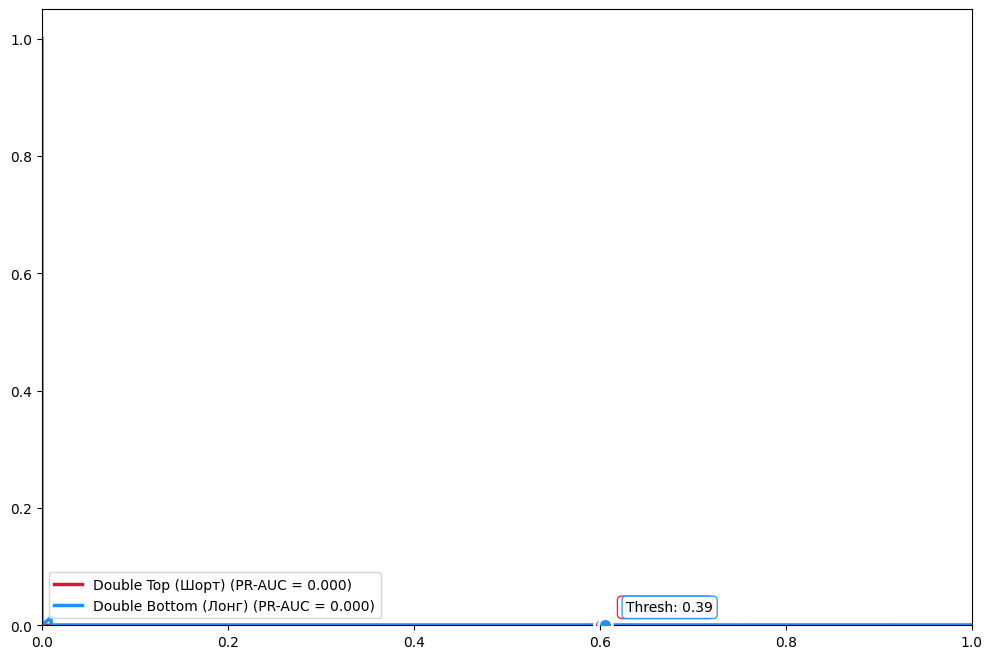


📊 Топ признаков по важности (Gain):


ValueError: All arrays must be of the same length

In [ ]:
# =========================================================
# ФИНАЛЬНАЯ ЯЧЕЙКА ОЦЕНКИ И ГРАФИКОВ
# =========================================================

TARGET_RECALL = CONFIG.target_recall
TOLERANCE = CONFIG.tolerance
NMS_WINDOW = CONFIG.nms_window

# Проверяем, что calibration/validation сохраняют полный noise.
calibration_dataset = DatasetPattern(
    X_calibration, y_calibration, CALIBRATION_GROUPS, training=False
)
validation_dataset = DatasetPattern(
    X_valid, y_valid, VALID_GROUPS, training=False
)
assert len(calibration_dataset) == len(X_calibration)
assert len(validation_dataset) == len(X_valid)
print("📊 Validation оставлен в боевом дисбалансе:")
print_dist(y_valid, "FULL VALIDATION SET")

# 1. Получаем вероятности отдельно для calibration и финальной validation.
print("📊 Расчет вероятностей на calibration и validation...")
y_calibration_probas = model.predict_proba(X_calibration)
y_valid_probas = model.predict_proba(X_valid)

# 2. Ищем пороги только на calibration, а финальные метрики считаем на validation.
thresh_dt, rec_dt, prec_dt = find_threshold_for_target_recall(
    y_calibration,
    y_calibration_probas,
    class_idx=CLASS_INDICES['DT'],
    target_recall=TARGET_RECALL
)
thresh_db, rec_db, prec_db = find_threshold_for_target_recall(
    y_calibration,
    y_calibration_probas,
    class_idx=CLASS_INDICES['DB'],
    target_recall=TARGET_RECALL
)

print('=' * 60)
print(f"🎯 ЖЕСТКИЙ ТАРГЕТ RECALL: {TARGET_RECALL * 100}%")
print(f"Double Top (DT) -> Найден порог: {thresh_dt:.4f} (Сырой Recall: {rec_dt:.2f})")
print(f"Double Bottom (DB) -> Найден порог: {thresh_db:.4f} (Сырой Recall: {rec_db:.2f})")
print('=' * 60)

# 3. Применяем пороги и кластеризацию (NMS)
y_pred_raw = apply_pattern_thresholds(y_valid_probas, threshold_dt=thresh_dt, threshold_db=thresh_db)
y_pred_valid = apply_nms_clustering(
    y_pred_raw,
    y_valid_probas,
    window_size=NMS_WINDOW,
    groups=VALID_GROUPS,
)

# 4. Расчет честных метрик по физическим фигурам с толерантностью
tp_1, fp_1, fn_1 = get_tolerant_indices(
    y_valid,
    y_pred_valid,
    class_idx=CLASS_INDICES['DT'],
    tolerance=TOLERANCE,
    groups=VALID_GROUPS
)
tp_2, fp_2, fn_2 = get_tolerant_indices(
    y_valid,
    y_pred_valid,
    class_idx=CLASS_INDICES['DB'],
    tolerance=TOLERANCE,
    groups=VALID_GROUPS
)

total_real_dt = count_physical_patterns(
    y_valid, class_idx=CLASS_INDICES['DT'], groups=VALID_GROUPS
)
total_real_db = count_physical_patterns(
    y_valid, class_idx=CLASS_INDICES['DB'], groups=VALID_GROUPS
)

caught_dt = total_real_dt - len(fn_1)
caught_db = total_real_db - len(fn_2)

real_recall_dt = caught_dt / total_real_dt if total_real_dt > 0 else 0
real_recall_db = caught_db / total_real_db if total_real_db > 0 else 0

total_signals_dt = len(tp_1) + len(fp_1)
total_signals_db = len(tp_2) + len(fp_2)

real_precision_dt = len(tp_1) / total_signals_dt if total_signals_dt > 0 else 0
real_precision_db = len(tp_2) / total_signals_db if total_signals_db > 0 else 0

candles_cnt = len(X_valid)

# 5. Красивый вывод бизнес-метрик
print("=" * 60)
print("🏆 РЕАЛЬНЫЕ БИЗНЕС-МЕТРИКИ ФИГУР (С УЧЕТОМ TOLERANCE И NMS)")
print("=" * 60)
print(f"Double Top (Двойная Вершина):")
print(f"  - Всего реальных фигур на графике: {total_real_dt}")
print(f"  - Из них пропущено ботом (FN):     {len(fn_1)}")
print(f"  - Из них поймано ботом (TP):       {len(tp_1)}")
print(f"  - Ложные входы в сделку (FP):      {len(fp_1)} | {len(fp_1) / candles_cnt * 100 : .2f}% от свечей")
print(f"  🎯 НАСТОЯЩИЙ RECALL (ПОЛНОТА):     {real_recall_dt * 100:.2f}%")
print(f"  🎯 НАСТОЯЩИЙ PRECISION (ТОЧНОСТЬ):  {real_precision_dt * 100:.2f}%")
print("-" * 60)
print(f"Double Bottom (Двойное Дно):")
print(f"  - Всего реальных фигур на графике: {total_real_db}")
print(f"  - Из них пропущено ботом (FN):     {len(fn_2)}")
print(f"  - Из них поймано ботом (TP):       {len(tp_2)}")
print(f"  - Ложные входы в сделку (FP):      {len(fp_2)} | {len(fp_2) / candles_cnt * 100 : .2f}% от свечей")
print(f"  🎯 НАСТОЯЩИЙ RECALL (ПОЛНОТА):     {real_recall_db * 100:.2f}%")
print(f"  🎯 НАСТОЯЩИЙ PRECISION (ТОЧНОСТЬ):  {real_precision_db * 100:.2f}%")
print(f"  Overall cnt of candles in valid: {candles_cnt}")
print(f"  Percent of FP is {(len(fp_2) + len(fp_1)) / candles_cnt * 100 : .2f}% comparing with candles cnt")
print("=" * 60)

# 6. Отрисовка PR-AUC графиков с защитой от ошибок Pandas
print("📊 Отрисовка PR-кривых...")
y_valid_arr = np.asarray(y_valid).flatten() # Защита от конфликта индексов
depict_pr_auc_custom_debug(y_valid, y_valid_probas, threshold_dt=thresh_dt, threshold_db=thresh_db)

depict_feature_importance(model, X_valid.columns)

In [ ]:
confidence_curves = plot_metrics_vs_confidence(
    y_true=y_valid,
    probas=y_valid_probas,
    class_indices=(CLASS_INDICES['DT'], CLASS_INDICES['DB']),
)

# Saving | loading model

## Constants for saving

In [ ]:
model_name="xgb_dtdb_detector_v1.json"
base_dir="/content/drive/MyDrive/Crypto_pattern_detection_models"

## Saving model

In [ ]:
def save_xgboost_model(model, model_name="xgb_dtdb_detector_v1.json",
                       base_dir="/content/drive/MyDrive/Crypto_pattern_detection_models"):
    """
    Сохраняет натренированную модель XGBoost на Google Drive.
    """
    # 1. Проверяем, примонтирован ли гугл диск (если нет - просим примонтировать)
    if not os.path.exists('/content/drive/MyDrive'):
        print("⚠️ Google Drive не примонтирован. Монтируем...")
        drive.mount('/content/drive')

    # 2. Создаем папку, если ее еще нет
    os.makedirs(base_dir, exist_ok=True)

    # 3. Формируем полный путь и сохраняем
    full_path = os.path.join(base_dir, model_name)
    model.save_model(full_path)

    print(f"✅ Модель успешно сохранена по пути:\n 📁 {full_path}")
    print(f"Размер файла: {os.path.getsize(full_path) / 1024:.2f} KB")

In [ ]:
save_xgboost_model(model, model_name=model_name, base_dir=base_dir)

✅ Модель успешно сохранена по пути:
 📁 /content/drive/MyDrive/Crypto_pattern_detection_models/xgb_dtdb_detector_v1.json
Размер файла: 728.88 KB


## Loading model

In [ ]:
def load_xgboost_model(model_name="xgb_dtdb_detector_v1.json",
                       base_dir="/content/drive/MyDrive/Crypto_pattern_detection_models"):
    """
    Загружает модель XGBoost из Google Drive.
    """
    # 1. Проверяем доступ к диску
    if not os.path.exists('/content/drive/MyDrive'):
        print("⚠️ Google Drive не примонтирован. Монтируем...")
        drive.mount('/content/drive')

    full_path = os.path.join(base_dir, model_name)

    # 2. Проверяем, существует ли файл
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"❌ Файл модели не найден: {full_path}")

    # 3. Инициализируем пустую модель и загружаем в нее веса
    print(f"⏳ Загрузка модели из:\n 📁 {full_path}...")
    loaded_model = xgb.XGBClassifier()
    loaded_model.load_model(full_path)

    print("✅ Модель успешно загружена и готова к предсказаниям!")
    return loaded_model

In [ ]:
model = load_xgboost_model(model_name=model_name, base_dir=base_dir)

⏳ Загрузка модели из:
 📁 /content/drive/MyDrive/Crypto_pattern_detection_models/xgb_dtdb_detector_v1.json...
✅ Модель успешно загружена и готова к предсказаниям!
